In [39]:
# Description:
#     This script creates files used to update the following fields on the highway network
#         - DISTANCE
#         - TAZID (links & nodes)
#         - HOT_ZONEID (links & nodes)
#     This script also creates the transit walk buffer file
#
#     Date Edited: 03/13/2024


# ============================================================================================================
# System setup
# ============================================================================================================
# print to console
print("")
print("Running Python Script: 'ip_UpdateNetwork_WalkBuffers.py'")
print("")
print("")
print("System setup...")


# ----------------------------------------------------------------------------------------
# import libraries
# ----------------------------------------------------------------------------------------
# print to console
print("")
print("    load python libraries")


# ------------------------------------------------------------------------------
# print to console
print("        importing system libraries")

# begin system library import
import time

# get time (in seconds)
time_begin = time.time()
time_begin_SysSetup = time.time()

# finish system library import
import os, sys, traceback
import importlib.machinery
from dbfread import DBF
import numpy as np
import math

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
import _global_scripts as gs
# ------------------------------------------------------------------------------
# print to console
print("        importing Pandas")

# import Pandas
import pandas as pd


# ------------------------------------------------------------------------------
# print to console
print("        importing GeoPandas and Shapely")

# import GeoPandas
import geopandas as gpd
import shapely



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#view all columns
pd.options.display.max_columns = None


Running Python Script: 'ip_UpdateNetwork_WalkBuffers.py'


System setup...

    load python libraries
        importing system libraries
        importing Pandas
        importing GeoPandas and Shapely


In [40]:
# ----------------------------------------------------------------------------------------
# Define Functions
# ----------------------------------------------------------------------------------------
# print to console
print("")
print("    define functions")

# import functions related to this script
import _updatenet_scripts as us

# calculate elapsed time -------------------------------------------------------
time_end_SysSetup     = time.time()
time_elapsed_SysSetup = time_end_SysSetup - time_begin_SysSetup

# format elapsed time (convert to string formated as 'HH:MM:SS.S')
time_elapsed_SysSetup_txt = gs.ElapsedTime(time_elapsed_SysSetup)

# print to console
print("")
print("    done")
print("    elapsed time: "  +  time_elapsed_SysSetup_txt)



    define functions

    done
    elapsed time: 00:00:00.0


In [41]:
# ============================================================================================================
# Global Parameters
# ============================================================================================================
print("")
print("")
print("Specifying Global Parameters & Input-Output Files...")


# get time (in seconds) --------------------------------------------------------
time_begin_GlobalParam = time.time()


# ----------------------------------------------------------------------------------------
# specify global parameters file & output files
# ----------------------------------------------------------------------------------------
# identify key variables -------------------------------------------------------
# specify input & output files
in_GlobalVar_txt      = "py_Variables - ip_GlobalVars.txt"

out_Log_txt           = "py_LogFile - ip_UpdateNetwork_WalkBuffers.txt"

out_Master_Link_csv   = "Updated_Master_Link.csv"
out_Master_Node_csv   = "Updated_Master_Node.csv"

out_Toll_Link_csv     = "Toll_Link.csv"
out_Toll_Node_csv     = "Toll_Node.csv"

out_Transit_Link_shp  = "Transit_Link.shp"
out_Transit_Node_shp  = "Transit_Node.shp"

out_WalkBuffer_shp    = "WalkBuffer.shp"
out_Scenario_Link_csv = "Scenario_Link_Direction.csv"
out_report1_csv       = "py_Debug - ip_duplicated-segments.csv"
out_report2_csv       = "py_Debug - ip_mismatched-segments.csv"
out_report3_csv       = "py_Debug - ip_mismatched-direction.csv"


# set buffer distance in miles
BuffDist_local   = 0.4
BuffDist_premium = 0.4

# set buffer distance in meters
BuffDist_segments = 50

# set max number of looping iterations if convergence isn't reached for segment direction
MaxIters = 12


# create global variables from input file --------------------------------------
# get path to script launch point (i.e. location of 'HailMary.s' or '*.ipynb')
dir_ScriptLaunch = os.getcwd()

# create path to global variables input file
# note: if running in jupyter notebooks
#       1) uncomment 2nd line
#       2) copy input global variables file to .ipynb location
path_in_GlobalVar_txt = os.path.join(dir_ScriptLaunch, "_Log", in_GlobalVar_txt)
path_in_GlobalVar_txt = os.path.join(dir_ScriptLaunch, in_GlobalVar_txt)


# create variables from input file global variables
GlobalVars = importlib.machinery.SourceFileLoader('data', path_in_GlobalVar_txt).load_module()

UsedZones   = GlobalVars.UsedZones
ParentDir   = GlobalVars.ParentDir
ScenarioDir = GlobalVars.ScenarioDir

in_TAZ_shp  = GlobalVars.TAZ_shp
in_Toll_shp = GlobalVars.TollZoneID_shp
TollZnField = GlobalVars.TollZoneField
in_Link_shp = GlobalVars.Master_Link_shp
in_Node_shp = GlobalVars.Master_Node_shp
in_Tran_dbf = GlobalVars.Transit_dbf
in_Segs_shp = GlobalVars.Segment_dbf.replace(".dbf", ".shp")


# create output folders --------------------------------------------------------
# create path to folders
path_outfolder_MasterNet     = os.path.join(ParentDir, ScenarioDir, "0_InputProcessing\\UpdatedMasterNet")
path_outfolder_MasterNet_GIS = os.path.join(ParentDir, ScenarioDir, "0_InputProcessing\\UpdatedMasterNet\\GIS")
path_outfolder_Transit       = os.path.join(ParentDir, ScenarioDir, "0_InputProcessing\\Transit")
path_outfolder_WalkBuffer    = os.path.join(ParentDir, ScenarioDir, "0_InputProcessing\\WalkBuffer")
path_outfolder_ScenarioNet   = os.path.join(ParentDir, ScenarioDir, "0_InputProcessing\\ScenarioNet")


# create folders
os.makedirs(path_outfolder_MasterNet,     exist_ok=True)
os.makedirs(path_outfolder_MasterNet_GIS, exist_ok=True)
os.makedirs(path_outfolder_Transit,       exist_ok=True)
os.makedirs(path_outfolder_WalkBuffer,    exist_ok=True)
os.makedirs(path_outfolder_ScenarioNet,   exist_ok=True)


# begin Log file ---------------------------------------------------------------
# create path to log file & open log file for writing
path_out_Log_txt = os.path.join(ParentDir, ScenarioDir, out_Log_txt)

logFile = open(path_out_Log_txt, 'w')


# print previous sections to log file (since log had not yet been defined)
logFile.write("\n")
logFile.write("Running Python Script: 'ip_UpdateNetwork_WalkBuffers.py'\n")
logFile.write("\n")
logFile.write("\n")
logFile.write("System setup...\n")
logFile.write("\n")
logFile.write("    load python libraries\n")
logFile.write("        importing system libraries\n")
logFile.write("        importing Pandas\n")
logFile.write("        importing GeoPandas\n")
logFile.write("\n")
logFile.write("    define functions\n")
logFile.write("\n")
logFile.write("    done\n")
logFile.write("    elapsed time: "  +  str(time_elapsed_SysSetup)  +  "\n")
logFile.write("\n")
logFile.write("\n")
logFile.write("Specifying Global Parameters & Input-Output Files...\n")


# print info for this section to console & log file ----------------------------
# print to console
print("")
print("    global parameters")
print("        from '" + in_GlobalVar_txt + "'")
print("             UsedZones        = "               +  str(UsedZones))
print("             ParentDir        = '"              +  ParentDir    +  "'")
print("             ScenarioDir      = ParentDir + '"  +  ScenarioDir  +  "'")
print("")
print("        other")
print("             dir_ScriptLaunch = '"              +  dir_ScriptLaunch  +  "'")
print("             BuffDist_local   = "               +  str(BuffDist_local))
print("             BuffDist_premium = "               +  str(BuffDist_premium))
print("")
print("    input files")
print("        from '" + in_GlobalVar_txt + "'")
print("             TAZ_shp          = ParentDir   + '1_Inputs\\1_TAZ\\"      +  in_TAZ_shp   +  "'")
print("             TollZoneID_shp   = ParentDir   + '1_Inputs\\3_Highway\\"  +  in_Toll_shp  +  "'")
print("                 (TollZoneField = '"  +  TollZnField  +  "')")
print("")
print("             Master_Link_shp  = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  in_Link_shp  +  "'")
print("             Master_Node_shp  = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  in_Node_shp  +  "'")
print("             Transit_dbf      = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  in_Tran_dbf  +  "'")
print("             Segment_shp      = ParentDir   + '1_Inputs\\6_Segment\\"      +  in_Segs_shp  +  "'")
print("")
print("    output files")
print("        out_Log_txt           = ScenarioDir + '"                                 +  out_Log_txt          +  "'")
print("        out_Transit_Link_shp  = ScenarioDir + '0_InputProcessing\\Transit\\"     +  out_Transit_Link_shp +  "'")
print("        out_Transit_Node_shp  = ScenarioDir + '0_InputProcessing\\Transit\\"     +  out_Transit_Node_shp +  "'")
print("        out_WalkBuffer_shp    = ScenarioDir + '0_InputProcessing\\WalkBuffer\\"  +  out_WalkBuffer_shp   +  "'")
print("")
print("        out_Master_Link_csv   = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  out_Master_Link_csv  +  "'")
print("        out_Master_Node_csv   = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  out_Master_Node_csv  +  "'")
print("        out_Toll_Link_csv     = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  out_Toll_Link_csv    +  "'")
print("        out_Toll_Node_csv     = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  out_Toll_Node_csv    +  "'")
print("")
print("        out_Scenario_Link_csv = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  out_Scenario_Link_csv  +  "'")
print("        out_report1_csv       = ScenarioDir + '_Log\\_debug\\"             +  out_report1_csv        +  "'")
print("        out_report2_csv       = ScenarioDir + '_Log\\_debug\\"             +  out_report2_csv        +  "'")
print("        out_report3_csv       = ScenarioDir + '_Log\\_debug\\"             +  out_report3_csv        +  "'")


# print to log file
logFile.write("\n")
logFile.write("    global parameters\n")
logFile.write("        from '" + in_GlobalVar_txt + "'\n")
logFile.write("             UsedZones        = "               +  str(UsedZones)  +  "\n")
logFile.write("             ParentDir        = '"              +  ParentDir       +  "'\n")
logFile.write("             ScenarioDir      = ParentDir + '"  +  ScenarioDir     +  "'\n")
logFile.write("\n")
logFile.write("        other\n")
logFile.write("             dir_ScriptLaunch = '"              +  dir_ScriptLaunch       +  "'\n")
logFile.write("             BuffDist_local   = "               +  str(BuffDist_local)    +  "\n")
logFile.write("             BuffDist_premium = "               +  str(BuffDist_premium)  +  "\n")
logFile.write("\n")
logFile.write("    input files\n")
logFile.write("        from '" + in_GlobalVar_txt + "'\n")
logFile.write("             TAZ_shp          = ParentDir   + '1_Inputs\\1_TAZ\\"      +  in_TAZ_shp   +  "'\n")
logFile.write("             TollZoneID_shp   = ParentDir   + '1_Inputs\\3_Highway\\"  +  in_Toll_shp  +  "'\n")
logFile.write("                 (TollZoneField = '"  +  TollZnField  +  "')\n")
logFile.write("\n")
logFile.write("             Master_Link_shp  = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  in_Link_shp  +  "'\n")
logFile.write("             Master_Node_shp  = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  in_Node_shp  +  "'\n")
logFile.write("             Transit_dbf      = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  in_Tran_dbf  +  "'\n")
logFile.write("             Segment_shp      = ParentDir   + '1_Inputs\\6_Segment\\"      +  in_Segs_shp  +  "'\n")
logFile.write("\n")
logFile.write("    output files\n")
logFile.write("        out_Log_txt           = ScenarioDir + '"                                 +  out_Log_txt          +  "'\n")
logFile.write("        out_Transit_Link_shp  = ScenarioDir + '0_InputProcessing\\Transit\\"     +  out_Transit_Link_shp +  "'\n")
logFile.write("        out_Transit_Node_shp  = ScenarioDir + '0_InputProcessing\\Transit\\"     +  out_Transit_Node_shp +  "'\n")
logFile.write("        out_WalkBuffer_shp    = ScenarioDir + '0_InputProcessing\\WalkBuffer\\"  +  out_WalkBuffer_shp   +  "'\n")
logFile.write("\n")
logFile.write("        out_Master_Link_csv   = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  out_Master_Link_csv  +  "'\n")
logFile.write("        out_Master_Node_csv   = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  out_Master_Node_csv  +  "'\n")
logFile.write("        out_Toll_Link_csv     = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  out_Toll_Link_csv    +  "'\n")
logFile.write("        out_Toll_Node_csv     = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  out_Toll_Node_csv    +  "'\n")
logFile.write("\n")
logFile.write("        out_Scenario_Link_csv = ScenarioDir + 'Temp\\0_InputProcessing\\"  +  out_Scenario_Link_csv  +  "'\n")
logFile.write("        out_report1_csv       = ScenarioDir + '_Log\\_debug\\"             +  out_report1_csv        +  "'\n")
logFile.write("        out_report2_csv       = ScenarioDir + '_Log\\_debug\\"             +  out_report2_csv        +  "'\n")
logFile.write("        out_report3_csv       = ScenarioDir + '_Log\\_debug\\"             +  out_report3_csv        +  "'\n")



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# close log file to see output of this step
#logFile.close()



Specifying Global Parameters & Input-Output Files...

    global parameters
        from 'py_Variables - ip_GlobalVars.txt'
             UsedZones        = 3629
             ParentDir        = 'D:\GitHub\WF-TDM-v9x\\'
             ScenarioDir      = ParentDir + 'Scenarios\WF TDM v910-Task2\Needs_2042\\'

        other
             dir_ScriptLaunch = 'd:\GitHub\WF-TDM-v9x\2_ModelScripts\_Python\_source - py script development'
             BuffDist_local   = 0.4
             BuffDist_premium = 0.4

    input files
        from 'py_Variables - ip_GlobalVars.txt'
             TAZ_shp          = ParentDir   + '1_Inputs\1_TAZ\WFv900_TAZ.dbf'
             TollZoneID_shp   = ParentDir   + '1_Inputs\3_Highway\_Toll Zone ID\TollZone.shp'
                 (TollZoneField = 'EL_Zone')

             Master_Link_shp  = ScenarioDir + 'Temp\0_InputProcessing\Master_Link_tmp0.shp'
             Master_Node_shp  = ScenarioDir + 'Temp\0_InputProcessing\Master_Node_tmp0.shp'
             Transit_dbf     

99

In [42]:
# ----------------------------------------------------------------------------------------
# read global variables into python
# ----------------------------------------------------------------------------------------
# print to console & log file
print("")
print("    Reading input file global variables...")

logFile.write("\n")
logFile.write("    Reading input file global variables...\n")


# set paths & read input files -------------------------------------------------
# create path to input file global variables 
path_in_TAZ_shp  = os.path.join(ParentDir, "1_Inputs\\1_TAZ", in_TAZ_shp)
path_in_Toll_shp = os.path.join(ParentDir, "1_Inputs\\3_Highway", in_Toll_shp)
path_in_Link_shp = os.path.join(ParentDir, ScenarioDir, "Temp\\0_InputProcessing", in_Link_shp)
path_in_Node_shp = os.path.join(ParentDir, ScenarioDir, "Temp\\0_InputProcessing", in_Node_shp)
path_in_Tran_dbf = os.path.join(ParentDir, ScenarioDir, "Temp\\0_InputProcessing", in_Tran_dbf)
path_in_Segs_shp = os.path.join(ParentDir, "1_Inputs\\6_Segment", in_Segs_shp)


# read in data & print to console & log file
print("        reading '"  +  in_TAZ_shp   +  "' into GeoDataFrame")
logFile.write("        reading '"  +  in_TAZ_shp   +  "' into GeoDataFrame\n")

gdf_TAZ  = gpd.read_file(path_in_TAZ_shp)


print("        reading '"  +  in_Toll_shp  +  "' into GeoDataFrame")
logFile.write("        reading '"  +  in_Toll_shp  +  "' into GeoDataFrame\n")
gdf_Toll = gpd.read_file(path_in_Toll_shp)


print("        reading '"  +  in_Link_shp  +  "' into GeoDataFrame")
logFile.write("        reading '"  +  in_Link_shp  +  "' into GeoDataFrame\n")
gdf_Master_link = gpd.read_file(path_in_Link_shp)


print("        reading '"  +  in_Node_shp  +  "' into GeoDataFrame")
logFile.write("        reading '"  +  in_Node_shp  +  "' into GeoDataFrame\n")
gdf_Master_node = gpd.read_file(path_in_Node_shp)


print("        reading '"  +  in_Tran_dbf  +  "' into DataFrame")
logFile.write("        reading '"  +  in_Tran_dbf  +  "' into DataFrame\n")

# read in transit link data from dbf file & convert dbf input file to pandas DataFrame
InputDBF_TransitLink = DBF(path_in_Tran_dbf)
df_TransitLinks = pd.DataFrame(iter(InputDBF_TransitLink))


print("        reading '"  +  in_Segs_shp  +  "' into DataFrame")
logFile.write("        reading '"  +  in_Segs_shp  +  "' into DataFrame\n")
gdf_Segments = gpd.read_file(path_in_Segs_shp)


# calculate elapsed time -------------------------------------------------------
time_end_GlobalParam     = time.time()
time_elapsed_GlobalParam = time_end_GlobalParam - time_begin_GlobalParam

# format elapsed time (convert to string formated as 'HH:MM:SS.S')
time_elapsed_GlobalParam_txt = gs.ElapsedTime(time_elapsed_GlobalParam)

# print to console & log file
print("")
print("    done")
print("    elapsed time: "  +  time_elapsed_GlobalParam_txt)

logFile.write("\n")
logFile.write("    done\n")
logFile.write("    elapsed time: "  +  time_elapsed_GlobalParam_txt  +  "\n")



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_TAZ.to_csv("_check\\chk0 - gdf_TAZ.csv" , index=False)
gdf_Toll.to_csv("_check\\chk0 - gdf_Toll.csv", index=False)
gdf_Master_link.to_csv("_check\\chk0 - gdf_Master_link.csv", index=False)
gdf_Master_node.to_csv("_check\\chk0 - gdf_Master_node.csv", index=False)
df_TransitLinks.to_csv("_check\\chk0 - df_TransitLinks.csv" , index=False)
gdf_Segments.to_csv("_check\\chk0 - gdf_Segments.csv", index=False)

print("----- data shape -----")
print("gdf_TAZ :", gdf_TAZ.shape )
print("gdf_Toll:", gdf_Toll.shape)
print("gdf_Master_link:", gdf_Master_link.shape)
print("gdf_Master_node:", gdf_Master_node.shape)
print("df_TransitLinks :", df_TransitLinks.shape )
print("gdf_Segments:", gdf_Segments.shape)

# close log file to see output of this step
#logFile.close()


    Reading input file global variables...
        reading 'WFv900_TAZ.dbf' into GeoDataFrame
        reading '_Toll Zone ID\TollZone.shp' into GeoDataFrame
        reading 'Master_Link_tmp0.shp' into GeoDataFrame
        reading 'Master_Node_tmp0.shp' into GeoDataFrame
        reading 'TransitLinks_tmp0.dbf' into DataFrame
        reading 'WFv910_Segments.shp' into DataFrame

    done
    elapsed time: 00:00:15.7
----- data shape -----
gdf_TAZ : (3546, 36)
gdf_Toll: (58, 6)
gdf_Master_link: (57810, 10)
gdf_Master_node: (21806, 6)
df_TransitLinks : (11374, 22)
gdf_Segments: (5480, 122)




Updating Master Net...

    update Master Net link DISTANCE field (calculating distance in miles)


,A,B,DISTANCE,LINKID,TAZID,HOT_ZONEID,LANES,FT,SEGID,geometry
0,1,29685,0.387704,1_29685,0,0,7,1,NaN,"LINESTRING (411935.000 4605642.000, 412478.126..."
1,2,29685,0.108710,2_29685,0,0,7,1,NaN,"LINESTRING (412641.000 4606013.000, 412478.126..."
2,3,29645,0.518017,3_29645,0,0,7,1,NaN,"LINESTRING (408993.000 4603544.000, 409632.415..."
3,4,29671,0.254196,4_29671,0,0,7,1,NaN,"LINESTRING (410051.000 4604806.000, 409642.112..."
4,5,29680,0.294677,5_29680,0,0,7,1,NaN,"LINESTRING (413394.000 4603600.000, 413482.000..."
...,...,...,...,...,...,...,...,...,...,...
57805,95064,95025,1.515087,95064_95025,0,0,1,7,2865_019.4,"LINESTRING (473181.550 4444171.200, 473172.240..."
57806,95064,95026,8.401280,95064_95026,0,0,1,7,2865_019.4,"LINESTRING (473181.550 4444171.200, 473177.690..."
57807,95064,95056,11.627499,95064_95056,0,0,1,7,NaN,"LINESTRING (473181.550 4444171.200, 473196.790..."
57808,95065,3621,0.105685,95065_3621,0,0,7,1,NaN,"LINESTRING (480730.710 4444037.000, 480767.876..."


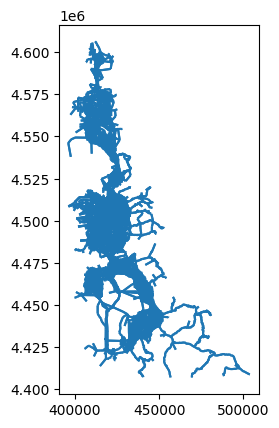

In [43]:
# ============================================================================================================
# Update Master Net
# ============================================================================================================
# print to console & log file
print("")
print("")
print("Updating Master Net...")

logFile.write("\n")
logFile.write("\n")
logFile.write("Updating Master Net...\n")


# get time (in seconds) --------------------------------------------------------
time_begin_MasterNet = time.time()


# ----------------------------------------------------------------------------------------
# update Master Net link distance
# ----------------------------------------------------------------------------------------
# print to console & log file
print("")
print("    update Master Net link DISTANCE field (calculating distance in miles)")

logFile.write("\n")
logFile.write("    update Master Net link DISTANCE field (calculating distance in miles)\n")


# update link distance field
gdf_Master_link["DISTANCE"] = gdf_Master_link.geometry.length / 1609.34



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Master_link.to_csv("_check\\Link_chk1 - gdf_Master_link - updated dist.csv", index=False)

gdf_Master_link.plot()
gdf_Master_link

# close log file to see output of this step
#logFile.close()


    calculate Master Net link midpoints


,A,B,DISTANCE,LINKID,TAZID,HOT_ZONEID,LANES,FT,SEGID,geometry,X_MID,Y_MID
0,1,29685,0.387704,1_29685,0,0,7,1,NaN,POINT (412206.563 4605795.562),412206.562800,4.605796e+06
1,2,29685,0.108710,2_29685,0,0,7,1,NaN,POINT (412559.563 4605981.062),412559.562800,4.605981e+06
2,3,29645,0.518017,3_29645,0,0,7,1,NaN,POINT (409312.708 4603276.537),409312.707700,4.603277e+06
3,4,29671,0.254196,4_29671,0,0,7,1,NaN,POINT (409846.556 4604799.603),409846.555850,4.604800e+06
4,5,29680,0.294677,5_29680,0,0,7,1,NaN,POINT (413438.000 4603833.000),413438.000000,4.603833e+06
...,...,...,...,...,...,...,...,...,...,...,...,...
57805,95064,95025,1.515087,95064_95025,0,0,1,7,2865_019.4,POINT (472476.057 4444465.636),472437.431233,4.444405e+06
57806,95064,95026,8.401280,95064_95026,0,0,1,7,2865_019.4,POINT (477286.484 4445393.618),477879.208798,4.446197e+06
57807,95064,95056,11.627499,95064_95056,0,0,1,7,NaN,POINT (475461.740 4438407.044),475807.847596,4.438365e+06
57808,95065,3621,0.105685,95065_3621,0,0,7,1,NaN,POINT (480749.293 4444119.987),480749.293150,4.444120e+06


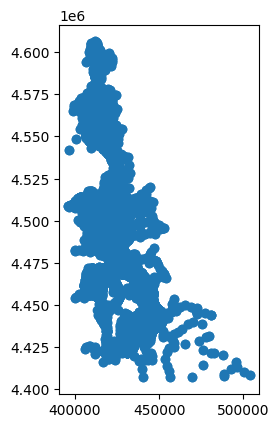

In [44]:
# ----------------------------------------------------------------------------------------
# calculate Master Net link midpoint
# ----------------------------------------------------------------------------------------
# print to console & log file
print("")
print("    calculate Master Net link midpoints")

logFile.write("\n")
logFile.write("    calculate Master Net link midpoints\n")


# copy Master Net link gdf & reset link geometry to midpoint
gdf_Master_link_mid = gdf_Master_link.copy()
gdf_Master_link_mid = gdf_Master_link_mid.set_geometry(gdf_Master_link_mid.geometry.centroid)



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#  add x & y coordinate to check geometry
gdf_Master_link_mid["X_MID"] = gdf_Master_link.geometry.interpolate(0.5, normalized=True).x
gdf_Master_link_mid["Y_MID"] = gdf_Master_link.geometry.interpolate(0.5, normalized=True).y

# check files
gdf_Master_link_mid.to_csv("_check\\Link_chk1 - gdf_Master_link_mid.csv", index=False)

gdf_Master_link_mid.plot()
gdf_Master_link_mid

# close log file to see output of this step
#logFile.close()


In [45]:
# ----------------------------------------------------------------------------------------
# update TAZID -- Links
# ----------------------------------------------------------------------------------------
# print to console & log file
print("")
print("    update Master Net link TAZID")

logFile.write("\n")
logFile.write("    update Master Net link TAZID\n")


# spatial join -------------------------------------------------------------
# print to console & log file
print("        spatial join TAZ to link midpoints")
logFile.write("        spatial join TAZ to link midpoints\n")


# spatial join Master Net link midpoints & TAZ
gdf_Master_link_mid_joinTAZ = gpd.sjoin_nearest(
    gdf_Master_link_mid, 
    gdf_TAZ, 
    distance_col='nearest_dist'
)

# drop duplicates where TAZ are equidistant from the link midpoint by keeping the first occurence
gdf_Master_link_mid_joinTAZ_unique = gdf_Master_link_mid_joinTAZ.drop_duplicates(
    subset='LINKID',
    keep='first',
    ignore_index=True
)



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Master_link_mid_joinTAZ.to_csv("_check\\Link_chk2 - gdf_Master_link_mid_joinTAZ.csv", index=False)
gdf_Master_link_mid_joinTAZ_unique.to_csv("_check\\Link_chk2 - gdf_Master_link_mid_joinTAZ_unique.csv", index=False)

print("\n")
print("----- data shape -----")
print("gdf_Master_link_mid_joinTAZ        :", gdf_Master_link_mid_joinTAZ.shape )
print("gdf_Master_link_mid_joinTAZ_unique :", gdf_Master_link_mid_joinTAZ_unique.shape)

# close log file to see output of this step
#logFile.close()


    update Master Net link TAZID
        spatial join TAZ to link midpoints


----- data shape -----
gdf_Master_link_mid_joinTAZ        : (57812, 49)
gdf_Master_link_mid_joinTAZ_unique : (57810, 49)


        update TAZID field


,A,B,DISTANCE,LINKID,TAZID,HOT_ZONEID,LANES,FT,SEGID,geometry,TAZID_left
0,1,29685,0.387704,1_29685,1,0,7,1,NaN,"LINESTRING (411935.000 4605642.000, 412478.126...",1
1,2,29685,0.108710,2_29685,2,0,7,1,NaN,"LINESTRING (412641.000 4606013.000, 412478.126...",2
2,3,29645,0.518017,3_29645,3,0,7,1,NaN,"LINESTRING (408993.000 4603544.000, 409632.415...",3
3,4,29671,0.254196,4_29671,4,0,7,1,NaN,"LINESTRING (410051.000 4604806.000, 409642.112...",4
4,5,29680,0.294677,5_29680,5,0,7,1,NaN,"LINESTRING (413394.000 4603600.000, 413482.000...",5
...,...,...,...,...,...,...,...,...,...,...,...
57805,95064,95025,1.515087,95064_95025,3536,0,1,7,2865_019.4,"LINESTRING (473181.550 4444171.200, 473172.240...",3536
57806,95064,95026,8.401280,95064_95026,3536,0,1,7,2865_019.4,"LINESTRING (473181.550 4444171.200, 473177.690...",3536
57807,95064,95056,11.627499,95064_95056,3538,0,1,7,NaN,"LINESTRING (473181.550 4444171.200, 473196.790...",3538
57808,95065,3621,0.105685,95065_3621,3621,0,7,1,NaN,"LINESTRING (480730.710 4444037.000, 480767.876...",3621


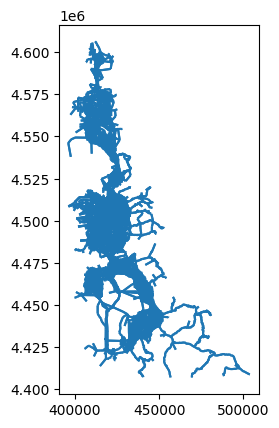

In [46]:
# update TAZID field -------------------------------------------------------
# print to console & log file
print("        update TAZID field")
logFile.write("        update TAZID field\n")


# set TAZID to be A or B node number if A or B value is <= UsedZones, otherwise use joined TAZID
#   note: calls 'calcTAZID_Link' function
gdf_Master_link_mid_joinTAZ_TAZID = gdf_Master_link_mid_joinTAZ_unique.copy()

gdf_Master_link_mid_joinTAZ_TAZID["TAZID_left"] = gdf_Master_link_mid_joinTAZ_TAZID.apply(
    lambda row: us.calcTAZID_Link(row["TAZID_right"], row["A"], row["B"], UsedZones), 
    axis=1
)

# select columns to include in table-join
df_Master_link_mid_joinTAZ_TAZID = gdf_Master_link_mid_joinTAZ_TAZID[
    ['LINKID',
     'TAZID_left']
]


# merge updated TAZID field to Master Net link gdf
gdf_Master_link_TAZID = pd.DataFrame.merge(
    gdf_Master_link,
    df_Master_link_mid_joinTAZ_TAZID,
    how="left",
    left_on='LINKID',
    right_on='LINKID'
)

# update TAZID field
gdf_Master_link_TAZID['TAZID'] = gdf_Master_link_TAZID['TAZID_left']



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Master_link_TAZID.to_csv("_check\\Link_chk3 - gdf_Master_link_TAZID.csv", index=False)

gdf_Master_link_TAZID.plot()
gdf_Master_link_TAZID

# close log file to see output of this step
#logFile.close()

        create output csv


,;A,B,DISTANCE,LINKID,TAZID
0,1,29685,0.387704,1_29685,1
1,2,29685,0.108710,2_29685,2
2,3,29645,0.518017,3_29645,3
3,4,29671,0.254196,4_29671,4
4,5,29680,0.294677,5_29680,5
...,...,...,...,...,...
57805,95064,95025,1.515087,95064_95025,3536
57806,95064,95026,8.401280,95064_95026,3536
57807,95064,95056,11.627499,95064_95056,3538
57808,95065,3621,0.105685,95065_3621,3621


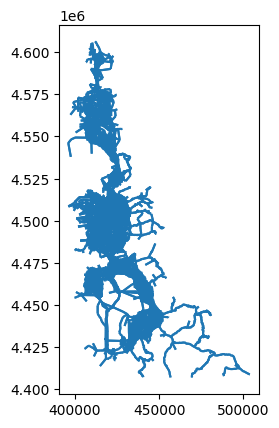

In [47]:
# create output csv --------------------------------------------------------
# print to console & log file
print("        create output csv")
logFile.write("        create output csv\n")


# create final updated Master link gdf
gdf_Master_link_final = gdf_Master_link_TAZID.drop(columns='TAZID_left')


# create final DataFrame & add ';' to first field name
df_Master_link_final = gdf_Master_link_final[
    ['A',
     'B',
     'DISTANCE',
     'LINKID',
     'TAZID']
].rename(
    columns={
        'A': ';A'
    }
)

# sort data
df_Master_link_final = df_Master_link_final.sort_values(
    by=[';A', 'B'],
    ascending=[True, True],
    ignore_index=True
)


# write data to csv file
path_out_Master_Link_csv = os.path.join(ParentDir, ScenarioDir, "Temp\\0_InputProcessing", out_Master_Link_csv)

df_Master_link_final.to_csv(
    path_out_Master_Link_csv,
    index=False
)



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Master_link_final.to_csv("_check\\Link_chk4 - gdf_Master_link_final.csv", index=False)

gdf_Master_link_final.plot()
df_Master_link_final

# close log file to see output of this step
#logFile.close()

In [48]:
# ----------------------------------------------------------------------------------------
# update TAZID -- Nodes
# ----------------------------------------------------------------------------------------
# print to console & log file
print("")
print("    update Master Net Node TAZID")

logFile.write("\n")
logFile.write("    update Master Net Node TAZID\n")


# spatial join -------------------------------------------------------------
# print to console & log file
print("        spatial join TAZ to nodes")
logFile.write("        spatial join TAZ to nodes\n")


# spatial join Master Net nodes & TAZ
gdf_Master_node_joinTAZ = gpd.sjoin_nearest(
    gdf_Master_node, 
    gdf_TAZ, 
    distance_col='nearest_dist'
)

# drop duplicates where TAZ are equidistant from the node by keeping the first occurence
gdf_Master_node_joinTAZ_unique = gdf_Master_node_joinTAZ.drop_duplicates(
    subset='N',
    keep='first',
    ignore_index=True
)



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Master_node_joinTAZ.to_csv("_check\\Node_chk1 - gdf_Master_node_joinTAZ.csv", index=False)
gdf_Master_node_joinTAZ_unique.to_csv("_check\\Node_chk1 - gdf_Master_node_joinTAZ_unique.csv", index=False)

print("\n")
print("----- data shape -----")
print("gdf_Master_node_joinTAZ        :", gdf_Master_node_joinTAZ.shape )
print("gdf_Master_node_joinTAZ_unique :", gdf_Master_node_joinTAZ_unique.shape)

# close log file to see output of this step
#logFile.close()


    update Master Net Node TAZID
        spatial join TAZ to nodes


----- data shape -----
gdf_Master_node_joinTAZ        : (21811, 43)
gdf_Master_node_joinTAZ_unique : (21806, 43)


        update TAZID field


,N,X,Y,TAZID,HOT_ZONEID,geometry,TAZID_left
0,1,411935.0000,4605642.000,1,0,POINT (411935.000 4605642.000),1
1,2,412641.0000,4606013.000,2,0,POINT (412641.000 4606013.000),2
2,3,408993.0000,4603544.000,3,0,POINT (408993.000 4603544.000),3
3,4,410051.0000,4604806.000,4,0,POINT (410051.000 4604806.000),4
4,5,413394.0000,4603600.000,5,0,POINT (413394.000 4603600.000),5
...,...,...,...,...,...,...,...
21801,95061,431050.6881,4422110.715,3469,0,POINT (431050.688 4422110.715),3469
21802,95062,430713.6121,4421517.072,3469,0,POINT (430713.612 4421517.072),3469
21803,95063,452850.1772,4468529.559,3508,0,POINT (452850.177 4468529.559),3508
21804,95064,473181.5500,4444171.200,3536,0,POINT (473181.550 4444171.200),3536


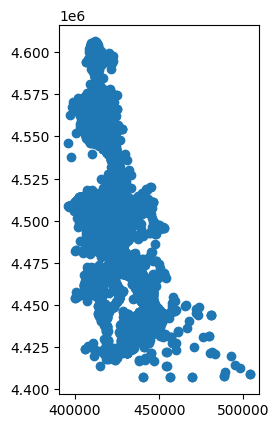

In [49]:
# update TAZID field -------------------------------------------------------
# print to console & log file
print("        update TAZID field")
logFile.write("        update TAZID field\n")


# set TAZID to be node number if N value is <= UsedZones, otherwise use joined TAZID
#   note: calls 'calcTAZID_Node' function
gdf_Master_node_joinTAZ_TAZID = gdf_Master_node_joinTAZ_unique.copy()

gdf_Master_node_joinTAZ_TAZID["TAZID_left"] = gdf_Master_node_joinTAZ_TAZID.apply(
    lambda row: us.calcTAZID_Node(row["TAZID_right"], row["N"], UsedZones), 
    axis=1
)

# select columns to include in table-join
df_Master_node_joinTAZ_TAZID = gdf_Master_node_joinTAZ_TAZID[
    ['N',
     'TAZID_left']
]


# merge updated TAZID field to Master Net node gdf
gdf_Master_node_TAZID = pd.DataFrame.merge(
    gdf_Master_node,
    df_Master_node_joinTAZ_TAZID,
    how="left",
    left_on='N',
    right_on='N'
)

# update TAZID field
gdf_Master_node_TAZID['TAZID'] = gdf_Master_node_TAZID['TAZID_left']



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Master_node_TAZID.to_csv("_check\\Node_chk2 - gdf_Master_node_TAZID.csv", index=False)

gdf_Master_node_TAZID.plot()
gdf_Master_node_TAZID

# close log file to see output of this step
#logFile.close()

        create output csv

    done
    elapsed time: 00:00:12.6


,;N,X,Y,TAZID
0,1,411935.0000,4605642.000,1
1,2,412641.0000,4606013.000,2
2,3,408993.0000,4603544.000,3
3,4,410051.0000,4604806.000,4
4,5,413394.0000,4603600.000,5
...,...,...,...,...
21801,95061,431050.6881,4422110.715,3469
21802,95062,430713.6121,4421517.072,3469
21803,95063,452850.1772,4468529.559,3508
21804,95064,473181.5500,4444171.200,3536


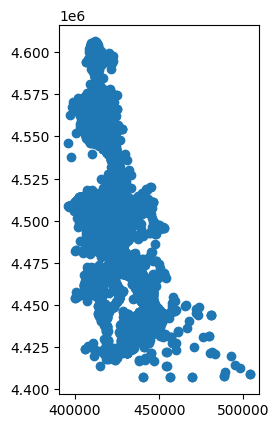

In [50]:
# create output csv --------------------------------------------------------
# print to console & log file
print("        create output csv")
logFile.write("        create output csv\n")


# create final updated Master node gdf
gdf_Master_node_final = gdf_Master_node_TAZID.drop(columns='TAZID_left')


# create final DataFrame & add ';' to first field name
df_Master_node_final = gdf_Master_node_final[
    ['N',
     'X',
     'Y',
     'TAZID']
].rename(
    columns={
        'N': ';N'
    }
)

# sort data
df_Master_node_final = df_Master_node_final.sort_values(
    by=';N',
    ascending=True,
    ignore_index=True
)


# write data to csv file
path_out_node_csv = os.path.join(ParentDir, ScenarioDir, "Temp\\0_InputProcessing", out_Master_Node_csv)

df_Master_node_final.to_csv(
    path_out_node_csv,
    index=False
)


# calculate elapsed time -------------------------------------------------------
time_end_MasterNet     = time.time()
time_elapsed_MasterNet = time_end_MasterNet - time_begin_MasterNet

# format elapsed time (convert to string formated as 'HH:MM:SS.S')
time_elapsed_MasterNet_txt = gs.ElapsedTime(time_elapsed_MasterNet)

# print to console & log file
print("")
print("    done")
print("    elapsed time: "  +  time_elapsed_MasterNet_txt)

logFile.write("\n")
logFile.write("    done\n")
logFile.write("    elapsed time: "  +  time_elapsed_MasterNet_txt  +  "\n")



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Master_node_final.to_csv("_check\\Node_chk3 - gdf_Master_node_final.csv", index=False)

gdf_Master_node_final.plot()
df_Master_node_final

# close log file to see output of this step
#logFile.close()

________________

In [51]:
# ============================================================================================================
# Preparing Files for Scenario Net Update
# ============================================================================================================

In [61]:
# ----------------------------------------------------------------------------------------
# Initialize Segments Dataset
# ----------------------------------------------------------------------------------------
#initialize segment df
gdf_Segments = gdf_Segments.rename(columns={'DIRECTION':'SEG_DIR', 'SEGID':'SEG_SEGID'})
gdf_Segments = gdf_Segments[['SEG_SEGID', 'SEG_DIR', 'BMP', 'EMP', 'geometry']]

# create a 50 meter buffer around the segments
gdf_Segments_Buffer = gdf_Segments[['SEG_SEGID', 'SEG_DIR','geometry']]
gdf_Segments_Buffer['geometry'] = gdf_Segments_Buffer['geometry'].buffer(BuffDist_segments)

# divide segment buffers to N/S and E/W directions
gdf_Segments_Buffer_NS = gdf_Segments_Buffer[gdf_Segments_Buffer['SEG_DIR'] == 'NB/SB']
gdf_Segments_Buffer_EW = gdf_Segments_Buffer[gdf_Segments_Buffer['SEG_DIR'] == 'EB/WB']

# initialize scenario link dataframe
planarea_taz = pd.DataFrame(gdf_TAZ[['TAZID','PLANAREA']])
gdf_Master_link_sn = pd.merge(gdf_Master_link_final,planarea_taz,on='TAZID',how='left')
gdf_Master_link_sn

# determine direction
gdf_Scearnio_Link = gdf_Master_link_sn.copy()
gdf_Scearnio_Link = gdf_Scearnio_Link.rename(columns={'SEGID':'NET_SEGID'})
gdf_Scearnio_Link['NET_DIR'] = gdf_Scearnio_Link['geometry'].apply(us.determine_link_direction)

d:\GitHub\WF-TDM-v9x\2_ModelScripts\_Python\py-tdm-env\lib\site-packages\geopandas\geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [62]:
# ----------------------------------------------------------------------------------------
# Merge Freeway Links and Segment Buffer
# ---------------------------------------------------------------------------------------- 
# print to console & log file
print("")
print("    merge freeway links and segment buffer")

logFile.write("\n")
logFile.write("    merge freeway links and segment buffer\n")

# filter to freeway links only
gdf_freeway_links = gdf_Scearnio_Link[
    ((gdf_Master_link_final['FT'].between(21, 27)) | 
     (gdf_Master_link_final['FT'].between(31, 38)) | 
     (gdf_Master_link_final['FT'] == 40))
]

# divide freeway links into N/S and E/W directions
gdf_freeway_ew_links = gdf_freeway_links[gdf_freeway_links['NET_DIR'].isin(['EB', 'WB'])]
gdf_freeway_ns_links = gdf_freeway_links[gdf_freeway_links['NET_DIR'].isin(['NB', 'SB'])]


    merge freeway links and segment buffer


In [65]:
# calculate segid from segment buffer using function
path_out_report1_csv = os.path.join(ParentDir, ScenarioDir,'_Log\\_debug\\', out_report1_csv)
gdf_ns_freeways_joined = us.get_segid_from_buffer(gdf_freeway_ns_links, gdf_Segments_Buffer_NS, gdf_Segments, 'Freeway', True , path_out_report1_csv)
gdf_ew_freeways_joined = us.get_segid_from_buffer(gdf_freeway_ew_links, gdf_Segments_Buffer_EW, gdf_Segments, 'Freeway', False, path_out_report1_csv)

d:\GitHub\WF-TDM-v9x\2_ModelScripts\_Python\py-tdm-env\lib\site-packages\geopandas\geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
d:\GitHub\WF-TDM-v9x\2_ModelScripts\_Python\py-tdm-env\lib\site-packages\IPython\core\interactiveshell.py:3550: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
d:\GitHub\WF-TDM-v9x\2_ModelScripts\_Python\py-tdm-env\lib\site-packages\geopandas\geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

In [71]:
# concatenate N/S and E/W datasets
gdf_freeway_links_pro = pd.concat([gdf_ns_freeways_joined, gdf_ew_freeways_joined], ignore_index=True)

# merge original segment attributes onto merge freeway dataset
df_Segments = pd.DataFrame(gdf_Segments).drop(columns={'geometry'})
gdf_freeway_links_pro = gdf_freeway_links_pro.merge(
    df_Segments, 
    left_on='SEGID', 
    right_on='SEG_SEGID', 
    how='left'
)

# calculate temporary direction field as a mix of segment direction and network direction
gdf_freeway_links_pro['DIRECTION'] =  gdf_freeway_links_pro.apply(
    lambda row: row['SEG_DIR'] if pd.notna(row['SEG_DIR']) else row['NET_DIR'], 
    axis=1
)

# drop columns
gdf_freeway_links_report = gdf_freeway_links_pro[['PLANAREA','LINKID','FTTYPE','FT','NET_SEGID','SEG_SEGID']]
gdf_freeway_links_final = gdf_freeway_links_pro.drop(columns={'SEG_SEGID','centroid', 'NET_SEGID'})

In [67]:

# ----------------------------------------------------------------------------------------
# Merge Non-Freeway Links and Segment Buffer
# ----------------------------------------------------------------------------------------
gdf_nonfreeway_links = gdf_Scearnio_Link[
    ~(
        (gdf_Master_link_final['FT'].between(21, 27)) | 
        (gdf_Master_link_final['FT'].between(31, 38)) | 
        (gdf_Master_link_final['FT'] == 40)           | 
        (gdf_Master_link_final['FT'] == 1)
    )
]

# divide freeway links into N/S and E/W directions
gdf_nonfreeway_ew_links = gdf_nonfreeway_links[gdf_nonfreeway_links['NET_DIR'].isin(['EB', 'WB'])]
gdf_nonfreeway_ns_links = gdf_nonfreeway_links[gdf_nonfreeway_links['NET_DIR'].isin(['NB', 'SB'])]

In [68]:
# get segid from buffer for non-freeway links (for reporting purposes)
gdf_ns_nonfreeway_joined = us.get_segid_from_buffer(gdf_nonfreeway_ns_links, gdf_Segments_Buffer_NS, gdf_Segments, 'Arterial', False, path_out_report1_csv)
gdf_ew_nonfreeway_joined = us.get_segid_from_buffer(gdf_nonfreeway_ew_links, gdf_Segments_Buffer_EW, gdf_Segments, 'Arterial', False, path_out_report1_csv)

d:\GitHub\WF-TDM-v9x\2_ModelScripts\_Python\py-tdm-env\lib\site-packages\geopandas\geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
d:\GitHub\WF-TDM-v9x\2_ModelScripts\_Python\py-tdm-env\lib\site-packages\IPython\core\interactiveshell.py:3550: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
d:\GitHub\WF-TDM-v9x\2_ModelScripts\_Python\py-tdm-env\lib\site-packages\geopandas\geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

In [69]:
# get final attributes for non-freeway links
gdf_nonfreeway_links_final = gdf_nonfreeway_links.merge(
    df_Segments, 
    left_on='NET_SEGID', 
    right_on='SEG_SEGID', 
    how='left'
)

# calculate temporary direction field as a mix of segment direction and network direction
gdf_nonfreeway_links_final['DIRECTION'] =  gdf_nonfreeway_links_final.apply(
    lambda row: row['SEG_DIR'] if pd.notna(row['SEG_DIR']) else row['NET_DIR'], 
    axis=1
)

# set FTTYPE values to distiguish between freeways and non-freeways
gdf_nonfreeway_links_final['FTTYPE'] = 'Non-Freeway'

# determine SEGID column to be used in processing
gdf_nonfreeway_links_final = gdf_nonfreeway_links_final.rename(columns={'NET_SEGID':'SEGID'}).drop(columns={'SEG_SEGID'})

In [70]:
# ----------------------------------------------------------------------------------------
# Concatenate Updated Freeway and Non-Freeway Links
# ----------------------------------------------------------------------------------------
# get centroid connectors
gdf_centconnector_links = gdf_Scearnio_Link[
    ((gdf_Master_link_final['FT'] == 1))
]
gdf_centconnector_links['FTTYPE'] = 'Centroid Connectors'
gdf_centconnector_links

# concatenate all link files
gdf_links_w_segids = pd.concat([gdf_freeway_links_final, gdf_nonfreeway_links_final, gdf_centconnector_links], ignore_index=True)

d:\GitHub\WF-TDM-v9x\2_ModelScripts\_Python\py-tdm-env\lib\site-packages\geopandas\geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [72]:
# ----------------------------------------------------------------------------------------
# Write output Report for Mismatched SEGIDs
# ----------------------------------------------------------------------------------------
# join nonfreeway variables that underwent joining with segment buffer
gdf_nonfreeway_links_report = pd.concat([gdf_ns_nonfreeway_joined, gdf_ew_nonfreeway_joined], ignore_index=True)

# merge original segment attributes onto merge freeway dataset
gdf_nonfreeway_links_report = gdf_nonfreeway_links_report.merge(
    df_Segments, 
    left_on='SEGID', 
    right_on='SEG_SEGID', 
    how='left'
)

# calculate temporary direction field as a mix of segment direction and network direction
gdf_nonfreeway_links_report['DIRECTION'] =  gdf_nonfreeway_links_report.apply(
    lambda row: row['SEG_DIR'] if pd.notna(row['SEG_DIR']) else row['NET_DIR'], 
    axis=1
)

# drop unneeded columns
gdf_nonfreeway_links_report = gdf_nonfreeway_links_report[['PLANAREA','LINKID','FTTYPE','FT','NET_SEGID','SEG_SEGID']]

In [73]:
# join reporting variables
report_links = pd.concat([gdf_freeway_links_report, gdf_nonfreeway_links_report], ignore_index=True)

# generate report in scenario directory
path_out_report2_csv = os.path.join(ParentDir, ScenarioDir,'_Log\\_debug\\', out_report2_csv)
us.make_mismatch_report(report_links, path_out_report2_csv)

In [74]:
# ----------------------------------------------------------------------------------------
# Update Direction based on overarching Segment Direction
# ----------------------------------------------------------------------------------------
gdf_direction = gdf_links_w_segids.copy()
gdf_direction['DIRECTION'] = gdf_direction.apply(us.update_direction, axis=1)

# get smaller dataframe to make it easier to work with
df_direction = pd.DataFrame(gdf_direction)[['PLANAREA','A','B','LINKID','FTTYPE','FT','SEGID','NET_DIR','SEG_DIR','DIRECTION']]

In [75]:
# set initial looping variables
df_direction['DIRECTION2'] = df_direction['DIRECTION']
previous_na_count = df_direction['DIRECTION'].isna().sum()  # Initial count of NaNs in the starting column
last_col = 'DIRECTION'

# loop through, using the fill_directions function, to determine missing directions; loop until functions stops improving answers or it hits 12 iterations
for i in range(2, MaxIters + 2):
    current_col = f'DIRECTION{i}'
    next_col = f'DIRECTION{i+1}'
    
    # Apply the fill_directions function and create the next column
    df_direction[next_col] = df_direction[current_col]
    df_direction = df_direction.groupby('SEGID', group_keys=False).apply(lambda g: us.fill_directions(g, next_col, current_col))
    
    # Check if the number of NaNs in the new column matches the previous column
    current_na_count = df_direction[next_col].isna().sum()
    if current_na_count == previous_na_count:
        break
    
    previous_na_count = current_na_count  # Update the previous NA count
    last_col = next_col  # Update the last column

In [76]:
# drop intermediate columns & rename
columns_to_drop = [f'DIRECTION{j}' for j in range(2, i + 2)] + ['DIRECTION']
if last_col in columns_to_drop:
    columns_to_drop.remove(last_col)
df_direction.drop(columns=columns_to_drop, inplace=True)
df_direction.rename(columns={last_col: 'DIRECTION_FINAL'}, inplace=True)

# fill last remaining na values with link direction (later print report of these values)
df_direction_final = df_direction.copy()
df_direction_final['DIRECTION_FINAL'] = df_direction_final['DIRECTION_FINAL'].fillna(df_direction_final['NET_DIR'])
df_direction_final = df_direction_final[['LINKID','DIRECTION_FINAL']]

<Axes: >

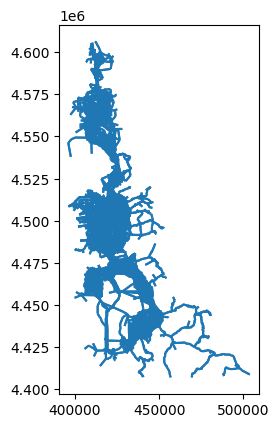

In [77]:
# create final geodataframe with updated DIRECTION field
gdf_links_w_direction = gdf_links_w_segids.merge(df_direction_final, on='LINKID', how='left')
gdf_links_w_direction['DIRECTION'] = gdf_links_w_direction['DIRECTION_FINAL'].fillna(gdf_links_w_direction['DIRECTION'])
gdf_links_w_direction['DIRECTION'] = gdf_links_w_direction['DIRECTION'].fillna(gdf_links_w_direction['NET_DIR'])
gdf_links_w_direction = gdf_links_w_direction[['A','B','DISTANCE','LINKID','LANES','FTTYPE','FT','DIRECTION','SEGID','geometry']]
gdf_links_w_direction

#save final output to temp folder
path_out_Scenario_Link_csv = os.path.join(ParentDir, ScenarioDir,"Temp\\0_InputProcessing", out_Scenario_Link_csv)
df_links_w_direction = pd.DataFrame(gdf_links_w_direction).drop(columns={'geometry'})
df_links_w_direction.to_csv(path_out_Scenario_Link_csv, index=False)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_links_w_direction.to_file("_check\\Scenario_Link_Direction.shp", index=False)

gdf_links_w_direction.plot()

# close log file to see output of this step
#logFile.close()

In [79]:
# ----------------------------------------------------------------------------------------
# Write output Report for Mismatched Direction
# ----------------------------------------------------------------------------------------
# Filter rows where 'DIRECTION_FINAL' is empty (NaN)
missing_direction_df = df_direction[df_direction['DIRECTION_FINAL'].isna()]

# Create a report with the desired columns and add the 'NOTES' column
report_df = missing_direction_df[['PLANAREA','LINKID', 'FTTYPE', 'SEGID']].copy()
report_df['NOTES'] = "Network Alightment Error; mismatch between segment direction and link direction"

# Save the report to a CSV file
path_out_report3_csv = os.path.join(ParentDir, ScenarioDir,'_Log\\_debug\\', out_report3_csv)
report_df.to_csv(path_out_report3_csv, index=False)

______________________



Creating Toll Zone ID Update Files...

    create link Toll Zone ID update file
        select eligible Toll links


<Axes: >

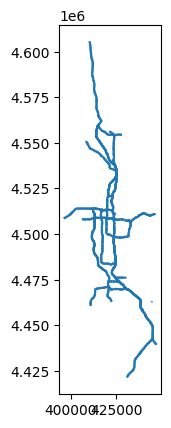

In [160]:
# ============================================================================================================
# Update Toll Zone ID
# ============================================================================================================
# print to console & log file
print("")
print("")
print("Creating Toll Zone ID Update Files...")

logFile.write("\n")
logFile.write("\n")
logFile.write("Creating Toll Zone ID Update Files...\n")


# get time (in seconds) --------------------------------------------------------
time_begin_TollZone = time.time()


# ----------------------------------------------------------------------------------------
# update Toll Zone ID -- links
# ----------------------------------------------------------------------------------------
# print to console & log file
print("")
print("    create link Toll Zone ID update file")

logFile.write("\n")
logFile.write("    create link Toll Zone ID update file\n")


# selecting eligible toll links ------------------------------------------------
# print to console & log file
print("        select eligible Toll links")
logFile.write("        select eligible Toll links\n")


# define eligible toll link selection criteria (i.e. scenario freeway links)
sel_TollLinks = (gdf_Master_link_final['LANES']>0) & (gdf_Master_link_final['FT']>=20) & (gdf_Master_link_final['FT']<=42)

# create toll link gdf
gdf_Toll_link = gdf_Master_link_final[sel_TollLinks]



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Toll_link.to_csv("_check\\Toll_chk1 - gdf_Toll_link.csv", index=False)

gdf_Toll_link.plot()

# close log file to see output of this step
#logFile.close()

        create link midpoints


<Axes: >

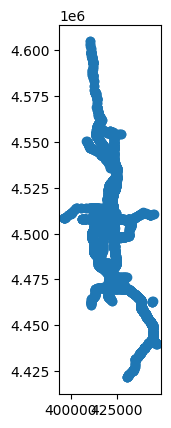

In [161]:
# creating toll link midpoints -------------------------------------------------
# print to console & log file
print("        create link midpoints")
logFile.write("        create link midpoints\n")

# reset link geometry to midpoint
gdf_Toll_link_mid = gdf_Toll_link.copy()

gdf_Toll_link_mid = gdf_Toll_link_mid.set_geometry(gdf_Toll_link_mid.geometry.centroid)



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Toll_link_mid.to_csv("_check\\Toll_chk1 - gdf_Toll_link_mid.csv", index=False)

gdf_Toll_link_mid.plot()

# close log file to see output of this step
#logFile.close()

In [162]:
# spatial join -----------------------------------------------------------------
# print to console & log file
print("        spatial join '" + in_Toll_shp + "' to link midpoints")
logFile.write("        spatial join '" + in_Toll_shp + "' to link midpoints\n")

# spatial join toll link midpoints & Toll Zone shapefile
gdf_Toll_link_mid_joinToll = gpd.sjoin(
    gdf_Toll_link_mid, 
    gdf_Toll, 
    how="left", 
    op="within"
)

# drop duplicates where TAZ are equidistant from the link midpoint by keeping the first occurence
gdf_Toll_link_mid_joinToll_unique = gdf_Toll_link_mid_joinToll.drop_duplicates(
    subset='LINKID',
    keep='first',
    ignore_index=True
)



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Toll_link_mid_joinToll.to_csv("_check\\Toll_chk2 - gdf_Toll_link_mid_joinToll.csv", index=False)
gdf_Toll_link_mid_joinToll_unique.to_csv("_check\\Toll_chk2 - gdf_Toll_link_mid_joinToll_unique.csv", index=False)

print("\n")
print("----- data shape -----")
print("gdf_Toll_link_mid_joinToll        :", gdf_Toll_link_mid_joinToll.shape )
print("gdf_Toll_link_mid_joinToll_unique :", gdf_Toll_link_mid_joinToll_unique.shape)

# close log file to see output of this step
#logFile.close()

        spatial join '_Toll Zone ID\TollZone.shp' to link midpoints


----- data shape -----
gdf_Toll_link_mid_joinToll        : (4763, 16)
gdf_Toll_link_mid_joinToll_unique : (4763, 16)


d:\GitHub\WF-TDM-v9x\2_ModelScripts\_Python\py-tdm-env\lib\site-packages\IPython\core\interactiveshell.py:3490: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


        update HOT_ZONEID


,A,B,DISTANCE,LINKID,TAZID,HOT_ZONEID,LANES,FT,SEGID,geometry,index_right,OBJECTID,Name,EL_Zone,Shape_Leng,Shape_Area
0,20134,62770,0.515028,20134_62770,2061,445.0,4,33,WFRC_8198,POINT (420830.826 4476592.789),36.0,314.0,MVC,445.0,40014.674561,3.949738e+06
1,20140,20173,0.688732,20140_20173,2061,440.0,4,33,WFRC_8198,POINT (420300.719 4477406.899),34.0,312.0,MVC,440.0,35880.210530,3.536103e+06
2,20150,20171,0.532772,20150_20171,2053,445.0,3,34,0085_005.8,POINT (415562.867 4482220.595),36.0,314.0,MVC,445.0,40014.674561,3.949738e+06
3,20154,20175,0.534478,20154_20175,2053,445.0,1,37,0085_005.8,POINT (415570.480 4482237.536),36.0,314.0,MVC,445.0,40014.674561,3.949738e+06
4,20155,20150,0.197556,20155_20150,2053,445.0,3,34,0085_006.0,POINT (415129.522 4482613.399),36.0,314.0,MVC,445.0,40014.674561,3.949738e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4758,90099,90100,0.222930,90099_90100,2203,NaN,1,41,NaN,POINT (438434.556 4510714.480),NaN,NaN,NaN,NaN,NaN,NaN
4759,90100,90059,0.486691,90100_90059,2203,NaN,4,33,NaN,POINT (437947.088 4510456.787),NaN,NaN,NaN,NaN,NaN,NaN
4760,90101,90090,0.141128,90101_90090,2207,NaN,4,33,NaN,POINT (438481.350 4510709.750),NaN,NaN,NaN,NaN,NaN,NaN
4761,90102,90103,0.056455,90102_90103,2207,NaN,1,42,NaN,POINT (438274.341 4510565.241),NaN,NaN,NaN,NaN,NaN,NaN


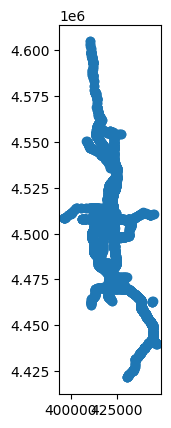

In [163]:
# update HOT_ZONEID ------------------------------------------------------------
# print to console & log file
print("        update HOT_ZONEID")
logFile.write("        update HOT_ZONEID\n")

# update HOT_ZONEID field
gdf_Toll_link_mid_joinToll_TollID = gdf_Toll_link_mid_joinToll_unique.copy()

gdf_Toll_link_mid_joinToll_TollID['HOT_ZONEID'] = gdf_Toll_link_mid_joinToll_TollID[TollZnField]



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Toll_link_mid_joinToll_TollID.to_csv("_check\\Toll_chk3 - gdf_Toll_link_mid_joinToll_TollID.csv", index=False)

gdf_Toll_link_mid_joinToll_TollID.plot()
gdf_Toll_link_mid_joinToll_TollID

# close log file to see output of this step
#logFile.close()

In [164]:
# write data to csv file -------------------------------------------------------
# print to console & log file
print("        create toll zone link csv")
logFile.write("        create toll zone link csv\n")


# create final DataFrame & add ';' to first field name
df_Toll_link_final = gdf_Toll_link_mid_joinToll_TollID[
    ['A',
     'B',
     'HOT_ZONEID']
].rename(
    columns={
        'A': ';A'
    }
)

# sort data
df_Toll_link_final = df_Toll_link_final.sort_values(
    by=[';A', 'B'],
    ascending=[True, True],
    ignore_index=True
)


# write out csv file
path_out_Toll_Link_csv = os.path.join(ParentDir, ScenarioDir, "Temp\\0_InputProcessing", out_Toll_Link_csv)

df_Toll_link_final.to_csv(
    path_out_Toll_Link_csv,
    index=False
)



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
df_Toll_link_final

# close log file to see output of this step
#logFile.close()

        create toll zone link csv


,;A,B,HOT_ZONEID
0,20134,62770,445.0
1,20140,20173,440.0
2,20150,20171,445.0
3,20154,20175,445.0
4,20155,20150,445.0
...,...,...,...
4758,90099,90100,NaN
4759,90100,90059,NaN
4760,90101,90090,NaN
4761,90102,90103,NaN



    create node Toll Zone ID update file
        select eligible Master Net nodes


<Axes: >

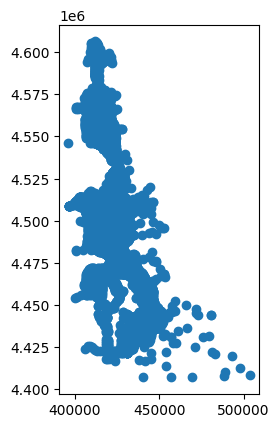

In [165]:
# ----------------------------------------------------------------------------------------
# update Toll Zone ID -- nodes
# ----------------------------------------------------------------------------------------
# print to console & log file
print("")
print("    create node Toll Zone ID update file")

logFile.write("\n")
logFile.write("    create node Toll Zone ID update file\n")


# selecting eligible toll nodes ------------------------------------------------
# print to console & log file
print("        select eligible Master Net nodes")
logFile.write("        select eligible Master Net nodes\n")

# define eligible toll link selection criteria
sel_TollNodes = (gdf_Master_node_final['N']>UsedZones)

# create toll node gdf
gdf_Toll_node = gdf_Master_node_final[sel_TollNodes]



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Toll_node.to_csv("_check\\Toll_chk1 - gdf_Toll_node.csv", index=False)

gdf_Toll_node.plot()

# close log file to see output of this step
#logFile.close()

In [166]:
# spatial join -----------------------------------------------------------------
# print to console & log file
print("        spatial join '" + in_Toll_shp + "' to nodes")
logFile.write("        spatial join '" + in_Toll_shp + "' to nodes\n")

# spatial join toll nodes & Toll Zone shapefile
gdf_Toll_node_joinToll = gpd.sjoin(
    gdf_Toll_node, 
    gdf_Toll, 
    how="left", 
    op="within"
)

# drop duplicates where TAZ are equidistant from the link midpoint by keeping the first occurence
gdf_Toll_node_joinToll_unique = gdf_Toll_node_joinToll.drop_duplicates(
    subset='N',
    keep='first',
    ignore_index=True
)



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Toll_node_joinToll.to_csv("_check\\Toll_chk2 - gdf_Toll_node_joinToll.csv", index=False)
gdf_Toll_node_joinToll_unique.to_csv("_check\\Toll_chk2 - gdf_Toll_node_joinToll_unique.csv", index=False)

print("\n")
print("----- data shape -----")
print("gdf_Toll_node_joinToll        :", gdf_Toll_node_joinToll.shape )
print("gdf_Toll_node_joinToll_unique :", gdf_Toll_node_joinToll_unique.shape)

# close log file to see output of this step
#logFile.close()

        spatial join '_Toll Zone ID\TollZone.shp' to nodes


d:\GitHub\WF-TDM-v9x\2_ModelScripts\_Python\py-tdm-env\lib\site-packages\IPython\core\interactiveshell.py:3490: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):




----- data shape -----
gdf_Toll_node_joinToll        : (18231, 12)
gdf_Toll_node_joinToll_unique : (18231, 12)


        update HOT_ZONEID


,N,X,Y,TAZID,HOT_ZONEID,geometry,index_right,OBJECTID,Name,EL_Zone,Shape_Leng,Shape_Area
0,10001,421814.0880,4477329.518,2185,NaN,POINT (421814.088 4477329.518),NaN,NaN,NaN,NaN,NaN,NaN
1,10002,421780.8954,4478149.861,2186,NaN,POINT (421780.895 4478149.861),NaN,NaN,NaN,NaN,NaN,NaN
2,10003,420953.0000,4479077.000,2186,NaN,POINT (420953.000 4479077.000),NaN,NaN,NaN,NaN,NaN,NaN
3,10004,420933.0000,4479869.000,2182,NaN,POINT (420933.000 4479869.000),NaN,NaN,NaN,NaN,NaN,NaN
4,10005,421113.0000,4480247.000,2182,NaN,POINT (421113.000 4480247.000),NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
18226,95061,431050.6881,4422110.715,3469,280.0,POINT (431050.688 4422110.715),51.0,331.0,I15,280.0,24906.596966,2.450641e+06
18227,95062,430713.6121,4421517.072,3469,280.0,POINT (430713.612 4421517.072),51.0,331.0,I15,280.0,24906.596966,2.450641e+06
18228,95063,452850.1772,4468529.559,3508,NaN,POINT (452850.177 4468529.559),NaN,NaN,NaN,NaN,NaN,NaN
18229,95064,473181.5500,4444171.200,3536,NaN,POINT (473181.550 4444171.200),NaN,NaN,NaN,NaN,NaN,NaN


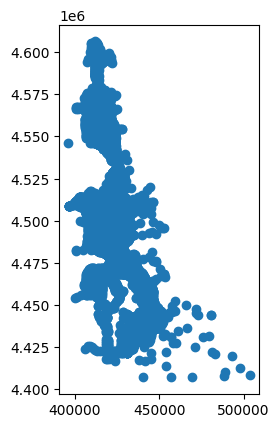

In [167]:
# update HOT_ZONEID ------------------------------------------------------------
# print to console & log file
print("        update HOT_ZONEID")
logFile.write("        update HOT_ZONEID\n")

# update HOT_ZONEID field
gdf_Toll_node_joinToll_TollID = gdf_Toll_node_joinToll_unique.copy()

gdf_Toll_node_joinToll_TollID['HOT_ZONEID'] = gdf_Toll_node_joinToll_TollID[TollZnField]



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Toll_node_joinToll_TollID.to_csv("_check\\Toll_chk3 - gdf_Toll_node_joinToll_TollID.csv", index=False)

gdf_Toll_node_joinToll_TollID.plot()
gdf_Toll_node_joinToll_TollID

# close log file to see output of this step
#logFile.close()

In [168]:
# write data to csv file -------------------------------------------------------
# print to console & log file
print("        create toll zone node csv")
logFile.write("        create toll zone node csv\n")


# create final DataFrame & add ';' to first field name
df_Toll_node_final = gdf_Toll_node_joinToll_TollID[
    ['N',
     'X',
     'Y',
     'HOT_ZONEID']
].rename(
    columns={
        'N': ';N'
    }
)

# sort data
df_Toll_node_final = df_Toll_node_final.sort_values(
    by=[';N'],
    ascending=[True],
    ignore_index=True
)


# write out csv file
path_out_Toll_Node_csv = os.path.join(ParentDir, ScenarioDir, "Temp\\0_InputProcessing", out_Toll_Node_csv)

df_Toll_node_final.to_csv(
    path_out_Toll_Node_csv,
    index=False
)


# calculate elapsed time -------------------------------------------------------
time_end_TollZone     = time.time()
time_elapsed_TollZone = time_end_TollZone - time_begin_TollZone

# format elapsed time (convert to string formated as 'HH:MM:SS.S')
time_elapsed_TollZone_txt = gs.ElapsedTime(time_elapsed_TollZone)

# print to console & log file
print("")
print("    done")
print("    elapsed time: "  +  time_elapsed_TollZone_txt)

logFile.write("\n")
logFile.write("    done\n")
logFile.write("    elapsed time: "  +  time_elapsed_TollZone_txt  +  "\n")



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
df_Toll_node_final

# close log file to see output of this step
#logFile.close()

        create toll zone node csv

    done
    elapsed time: 00:00:02.4


,;N,X,Y,HOT_ZONEID
0,10001,421814.0880,4477329.518,NaN
1,10002,421780.8954,4478149.861,NaN
2,10003,420953.0000,4479077.000,NaN
3,10004,420933.0000,4479869.000,NaN
4,10005,421113.0000,4480247.000,NaN
...,...,...,...,...
18226,95061,431050.6881,4422110.715,280.0
18227,95062,430713.6121,4421517.072,280.0
18228,95063,452850.1772,4468529.559,NaN
18229,95064,473181.5500,4444171.200,NaN


In [169]:
# ============================================================================================================
# Create Transit Shapefiles
# ============================================================================================================
# print to console & log file
print("")
print("")
print("Creating Transit Shapefiles...")

logFile.write("\n")
logFile.write("\n")
logFile.write("Creating Transit Shapefiles...\n")


# get time (in seconds) --------------------------------------------------------
time_begin_TransitShp = time.time()


# ----------------------------------------------------------------------------------------
# create Transit link shapefile
# ----------------------------------------------------------------------------------------
# print to console & log file
print("")
print("    create Transit link shapefile")

logFile.write("\n")
logFile.write("    create Transit link shapefile\n")


# join updated Master link data to Transit link data ---------------------------
# print to console & log file
print("        join updated Master link data to Transit link data")
logFile.write("        join updated Master link data to Transit link data\n")


# merge updated Master Net link data to Transit link df
df_TransitLinks_Master = pd.DataFrame.merge(
    df_TransitLinks,
    gdf_Master_link_final,
    how="left",
    left_on=['A', 'B'],
    right_on=['A', 'B']
)



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
df_TransitLinks_Master

# close log file to see output of this step
#logFile.close()



Creating Transit Shapefiles...

    create Transit link shapefile
        join updated Master link data to Transit link data


,A,B,MODE,OPERATOR,NAME,LONGNAME,DIST,TIME,LINKSEQ,HEADWAY_1,STOPA,STOPB,VOL,ONA,OFFA,ONB,OFFB,REV_VOL,REV_ONA,REV_OFFA,REV_ONB,REV_OFFB,DISTANCE,LINKID,TAZID,HOT_ZONEID,LANES,FT,SEGID,geometry
0,10031,27082,4,0,S455,S455,0.24,25.00,1,30.0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.240831,10031_27082,780.0,0.0,7.0,1.0,UTA_1004,"LINESTRING (423905.095 4537796.948, 423535.941..."
1,27082,27137,4,0,S455,S455,0.15,25.00,2,30.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.146744,27082_27137,775.0,0.0,2.0,2.0,1459_003.9,"LINESTRING (423535.941 4537678.869, 423696.154..."
2,27137,27082,4,0,S455,S455,0.15,25.00,3,30.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.146744,27137_27082,775.0,0.0,2.0,2.0,1459_003.9,"LINESTRING (423696.154 4537852.373, 423535.941..."
3,27082,27053,4,0,S455,S455,0.09,25.00,4,30.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.090994,27082_27053,775.0,0.0,2.0,3.0,1459_003.6,"LINESTRING (423535.941 4537678.869, 423438.000..."
4,27053,27004,4,0,S455,S455,0.16,25.00,5,30.0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.163048,27053_27004,780.0,0.0,2.0,3.0,1459_003.6,"LINESTRING (423438.000 4537570.000, 423271.523..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11369,55039,50024,12,0,*12,*12,0.01,0.24,70,0.0,0,0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
11370,67413,2848,12,0,*12,*12,0.20,4.80,71,0.0,0,0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
11371,67421,2848,12,0,*12,*12,0.20,4.80,72,0.0,0,0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
11372,67456,2848,12,0,*12,*12,0.20,4.80,73,0.0,0,0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.417004,67456_2848,2848.0,0.0,7.0,1.0,NaN,"LINESTRING (439778.466 4458956.252, 439108.770..."


In [170]:
# filter data to only include transit modes & select fields --------------------
# print to console & log file
print("        filter data to only include transit modes & select fields")
logFile.write("        filter data to only include transit modes & select fields\n")


# only include transit modes
df_TransitLinks_Master_Filter = df_TransitLinks_Master[
    (df_TransitLinks_Master.MODE>=1) & 
    (df_TransitLinks_Master.MODE<=9)
]

# only include select fields
df_TransitLinks_Master_Filter = df_TransitLinks_Master_Filter[
    ['A',
     'B',
     'LINKID',
     'MODE',
     'OPERATOR',
     'NAME',
     'LONGNAME',
     'LINKSEQ',
     'STOPA',
     'STOPB',
     'DISTANCE',
     'TAZID',
     'LANES',
     'FT',
     'geometry']
]



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
df_TransitLinks_Master_Filter

# close log file to see output of this step
#logFile.close()

        filter data to only include transit modes & select fields


,A,B,LINKID,MODE,OPERATOR,NAME,LONGNAME,LINKSEQ,STOPA,STOPB,DISTANCE,TAZID,LANES,FT,geometry
0,10031,27082,10031_27082,4,0,S455,S455,1,1,0,0.240831,780.0,7.0,1.0,"LINESTRING (423905.095 4537796.948, 423535.941..."
1,27082,27137,27082_27137,4,0,S455,S455,2,0,0,0.146744,775.0,2.0,2.0,"LINESTRING (423535.941 4537678.869, 423696.154..."
2,27137,27082,27137_27082,4,0,S455,S455,3,0,0,0.146744,775.0,2.0,2.0,"LINESTRING (423696.154 4537852.373, 423535.941..."
3,27082,27053,27082_27053,4,0,S455,S455,4,0,0,0.090994,775.0,2.0,3.0,"LINESTRING (423535.941 4537678.869, 423438.000..."
4,27053,27004,27053_27004,4,0,S455,S455,5,0,1,0.163048,780.0,2.0,3.0,"LINESTRING (423438.000 4537570.000, 423271.523..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11295,15178,15177,15178_15177,7,0,POM_Rail-,Point of Mountain Rail,73,0,1,0.534939,2134.0,0.0,70.0,"LINESTRING (423454.883 4483631.942, 423441.699..."
11296,15177,15027,15177_15027,7,0,POM_Rail-,Point of Mountain Rail,74,1,0,0.089815,2134.0,0.0,70.0,"LINESTRING (423441.699 4484492.741, 423388.247..."
11297,15027,15026,15027_15026,7,0,POM_Rail-,Point of Mountain Rail,75,0,0,0.082373,2127.0,0.0,70.0,"LINESTRING (423388.247 4484627.038, 423274.967..."
11298,15026,15028,15026_15028,7,0,POM_Rail-,Point of Mountain Rail,76,0,0,0.113679,2117.0,0.0,70.0,"LINESTRING (423274.967 4484695.895, 423363.814..."


In [171]:
# remove the '-' character from end of reverse route names ---------------------
# print to console & log file
print("        remove the '-' character from end of reverse route names")
logFile.write("        remove the '-' character from end of reverse route names\n")


# remove the '-' character from end route name
df_TransitLinks_Master_Filter_Rename = df_TransitLinks_Master_Filter.copy()

df_TransitLinks_Master_Filter_Rename['NAME'] = df_TransitLinks_Master_Filter_Rename['NAME'].apply(
    lambda x: x[:-1] if x.endswith('-') else x
)



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
df_TransitLinks_Master_Filter_Rename

# close log file to see output of this step
#logFile.close()

        remove the '-' character from end of reverse route names


,A,B,LINKID,MODE,OPERATOR,NAME,LONGNAME,LINKSEQ,STOPA,STOPB,DISTANCE,TAZID,LANES,FT,geometry
0,10031,27082,10031_27082,4,0,S455,S455,1,1,0,0.240831,780.0,7.0,1.0,"LINESTRING (423905.095 4537796.948, 423535.941..."
1,27082,27137,27082_27137,4,0,S455,S455,2,0,0,0.146744,775.0,2.0,2.0,"LINESTRING (423535.941 4537678.869, 423696.154..."
2,27137,27082,27137_27082,4,0,S455,S455,3,0,0,0.146744,775.0,2.0,2.0,"LINESTRING (423696.154 4537852.373, 423535.941..."
3,27082,27053,27082_27053,4,0,S455,S455,4,0,0,0.090994,775.0,2.0,3.0,"LINESTRING (423535.941 4537678.869, 423438.000..."
4,27053,27004,27053_27004,4,0,S455,S455,5,0,1,0.163048,780.0,2.0,3.0,"LINESTRING (423438.000 4537570.000, 423271.523..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11295,15178,15177,15178_15177,7,0,POM_Rail,Point of Mountain Rail,73,0,1,0.534939,2134.0,0.0,70.0,"LINESTRING (423454.883 4483631.942, 423441.699..."
11296,15177,15027,15177_15027,7,0,POM_Rail,Point of Mountain Rail,74,1,0,0.089815,2134.0,0.0,70.0,"LINESTRING (423441.699 4484492.741, 423388.247..."
11297,15027,15026,15027_15026,7,0,POM_Rail,Point of Mountain Rail,75,0,0,0.082373,2127.0,0.0,70.0,"LINESTRING (423388.247 4484627.038, 423274.967..."
11298,15026,15028,15026_15028,7,0,POM_Rail,Point of Mountain Rail,76,0,0,0.113679,2117.0,0.0,70.0,"LINESTRING (423274.967 4484695.895, 423363.814..."


        create Transit link shapefile


<Axes: >

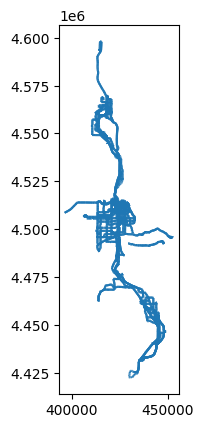

In [172]:
# create Transit link shapefile ------------------------------------------------
# print to console & log file
print("        create Transit link shapefile")
logFile.write("        create Transit link shapefile\n")


# use merged geometry to create gdf
gdf_Transit_Link = gpd.GeoDataFrame(df_TransitLinks_Master_Filter_Rename)


# set TAZID, LANES & FT fields back to integer
gdf_Transit_Link['TAZID'] = gdf_Transit_Link['TAZID'].astype(int)
gdf_Transit_Link['LANES'] = gdf_Transit_Link['LANES'].astype(int)
gdf_Transit_Link['FT']    = gdf_Transit_Link['FT'].astype(int)


# export to shapefile
path_out_Transit_Link_shp = os.path.join(path_outfolder_Transit, out_Transit_Link_shp)

gdf_Transit_Link.to_file(
    path_out_Transit_Link_shp,
    driver='ESRI Shapefile'
)


# remove geometry from transit link gdf
df_Transit_Link = gdf_Transit_Link.drop(columns='geometry')



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Transit_Link.to_csv("_check\\Transit_chk1 - gdf_Transit_Link.csv", index=False)

gdf_Transit_Link.plot()

# close log file to see output of this step
#logFile.close()

In [173]:
# ----------------------------------------------------------------------------------------
# create Transit node shapefile
# ----------------------------------------------------------------------------------------
# print to console & log file
print("")
print("    create Transit node shapefile")

logFile.write("\n")
logFile.write("    create Transit node shapefile\n")


# process Transit link data for Transit node extraction ------------------------
# print to console & log file
print("        process Transit link data for Transit node extraction")
logFile.write("        process Transit link data for Transit node extraction\n")


# add stops by mode columns
df_Transit_Link_Stops = df_Transit_Link.copy()

df_Transit_Link_Stops['STOP4'] = 0
df_Transit_Link_Stops['STOP5'] = 0
df_Transit_Link_Stops['STOP6'] = 0
df_Transit_Link_Stops['STOP7'] = 0
df_Transit_Link_Stops['STOP8'] = 0
df_Transit_Link_Stops['STOP9'] = 0



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
df_Transit_Link_Stops

# close log file to see output of this step
#logFile.close()


    create Transit node shapefile
        process Transit link data for Transit node extraction


,A,B,LINKID,MODE,OPERATOR,NAME,LONGNAME,LINKSEQ,STOPA,STOPB,DISTANCE,TAZID,LANES,FT,STOP4,STOP5,STOP6,STOP7,STOP8,STOP9
0,10031,27082,10031_27082,4,0,S455,S455,1,1,0,0.240831,780,7,1,0,0,0,0,0,0
1,27082,27137,27082_27137,4,0,S455,S455,2,0,0,0.146744,775,2,2,0,0,0,0,0,0
2,27137,27082,27137_27082,4,0,S455,S455,3,0,0,0.146744,775,2,2,0,0,0,0,0,0
3,27082,27053,27082_27053,4,0,S455,S455,4,0,0,0.090994,775,2,3,0,0,0,0,0,0
4,27053,27004,27053_27004,4,0,S455,S455,5,0,1,0.163048,780,2,3,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11295,15178,15177,15178_15177,7,0,POM_Rail,Point of Mountain Rail,73,0,1,0.534939,2134,0,70,0,0,0,0,0,0
11296,15177,15027,15177_15027,7,0,POM_Rail,Point of Mountain Rail,74,1,0,0.089815,2134,0,70,0,0,0,0,0,0
11297,15027,15026,15027_15026,7,0,POM_Rail,Point of Mountain Rail,75,0,0,0.082373,2127,0,70,0,0,0,0,0,0
11298,15026,15028,15026_15028,7,0,POM_Rail,Point of Mountain Rail,76,0,0,0.113679,2117,0,70,0,0,0,0,0,0


In [174]:
# extract A & B node data from links -------------------------------------------
# print to console & log file
print("        extract A & B node data from links")
logFile.write("        extract A & B node data from links\n")


# filter & rename columns
df_Transit_Node_A = df_Transit_Link_Stops[
    ['A',
     'MODE',
     'OPERATOR',
     'NAME',
     'LONGNAME',
     'STOPA',
     'STOP4',
     'STOP5',
     'STOP6',
     'STOP7',
     'STOP8',
     'STOP9']
].rename(
    columns={
        'A'    : 'N',
        'STOPA': 'STOP'
    }
)

df_Transit_Node_B = df_Transit_Link_Stops[
    ['B',
     'MODE',
     'OPERATOR',
     'NAME',
     'LONGNAME',
     'STOPB',
     'STOP4',
     'STOP5',
     'STOP6',
     'STOP7',
     'STOP8',
     'STOP9']
].rename(
    columns={
        'B'    : 'N',
        'STOPB': 'STOP'
    }
)


# combine data
df_Transit_Node_combined= pd.concat(
    [df_Transit_Node_A,
     df_Transit_Node_B]
)


# keep only unique records
df_Transit_Node_combined_unique = df_Transit_Node_combined.drop_duplicates(
    subset=['N', 'NAME'],
    keep='first',
    ignore_index=True
)



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
df_Transit_Node_combined_unique

# close log file to see output of this step
#logFile.close()

        extract A & B node data from links


,N,MODE,OPERATOR,NAME,LONGNAME,STOP,STOP4,STOP5,STOP6,STOP7,STOP8,STOP9
0,10031,4,0,S455,S455,1,0,0,0,0,0,0
1,27082,4,0,S455,S455,0,0,0,0,0,0,0
2,27137,4,0,S455,S455,0,0,0,0,0,0,0
3,27053,4,0,S455,S455,0,0,0,0,0,0,0
4,27004,4,0,S455,S455,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6321,20870,4,0,SF453,SF453,1,0,0,0,0,0,0
6322,29381,5,0,BRTNSDA_R,Ext of DavisSLCCon,1,0,0,0,0,0,0
6323,10010,5,0,SoJoSandyC,South Jordan/Sandy Circulator,1,0,0,0,0,0,0
6324,25439,6,0,S472X,S472X,1,0,0,0,0,0,0


In [175]:
# calculate stop by mode columns -----------------------------------------------
# print to console & log file
print("        calculate stop by mode columns")
logFile.write("        calculate stop by mode columns\n")


# filter & rename columns
df_Transit_Node_CalcStop = df_Transit_Node_combined_unique.copy()

df_Transit_Node_CalcStop.loc[(df_Transit_Node_CalcStop['MODE']==4) & (df_Transit_Node_CalcStop['STOP']==1), 'STOP4'] = 1
df_Transit_Node_CalcStop.loc[(df_Transit_Node_CalcStop['MODE']==5) & (df_Transit_Node_CalcStop['STOP']==1), 'STOP5'] = 1
df_Transit_Node_CalcStop.loc[(df_Transit_Node_CalcStop['MODE']==6) & (df_Transit_Node_CalcStop['STOP']==1), 'STOP6'] = 1
df_Transit_Node_CalcStop.loc[(df_Transit_Node_CalcStop['MODE']==7) & (df_Transit_Node_CalcStop['STOP']==1), 'STOP7'] = 1
df_Transit_Node_CalcStop.loc[(df_Transit_Node_CalcStop['MODE']==8) & (df_Transit_Node_CalcStop['STOP']==1), 'STOP8'] = 1
df_Transit_Node_CalcStop.loc[(df_Transit_Node_CalcStop['MODE']==9) & (df_Transit_Node_CalcStop['STOP']==1), 'STOP9'] = 1



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
df_Transit_Node_CalcStop

# close log file to see output of this step
#logFile.close()

        calculate stop by mode columns


,N,MODE,OPERATOR,NAME,LONGNAME,STOP,STOP4,STOP5,STOP6,STOP7,STOP8,STOP9
0,10031,4,0,S455,S455,1,1,0,0,0,0,0
1,27082,4,0,S455,S455,0,0,0,0,0,0,0
2,27137,4,0,S455,S455,0,0,0,0,0,0,0
3,27053,4,0,S455,S455,0,0,0,0,0,0,0
4,27004,4,0,S455,S455,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6321,20870,4,0,SF453,SF453,1,1,0,0,0,0,0
6322,29381,5,0,BRTNSDA_R,Ext of DavisSLCCon,1,0,1,0,0,0,0
6323,10010,5,0,SoJoSandyC,South Jordan/Sandy Circulator,1,0,1,0,0,0,0
6324,25439,6,0,S472X,S472X,1,0,0,1,0,0,0


In [176]:
# join updated Master node data to Transit node data ---------------------------
# print to console & log file
print("        join updated Master node data to Transit node data")
logFile.write("        join updated Master node data to Transit node data\n")


# merge updated Master Net node data to Transit node df
df_Transit_Node_CalcStop_Master = pd.DataFrame.merge(
    df_Transit_Node_CalcStop,
    gdf_Master_node_final,
    how="left",
    left_on=['N'],
    right_on=['N']
)

df_Transit_Node_CalcStop_Master_Filter = df_Transit_Node_CalcStop_Master[
    ['N',
     'MODE',
     'OPERATOR',
     'NAME',
     'LONGNAME',
     'STOP',
     'STOP4',
     'STOP5',
     'STOP6',
     'STOP7',
     'STOP8',
     'STOP9',
     'X',
     'Y',
     'TAZID',
     'geometry']
]



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
df_Transit_Node_CalcStop_Master_Filter

# close log file to see output of this step
#logFile.close()

        join updated Master node data to Transit node data


,N,MODE,OPERATOR,NAME,LONGNAME,STOP,STOP4,STOP5,STOP6,STOP7,STOP8,STOP9,X,Y,TAZID,geometry
0,10031,4,0,S455,S455,1,1,0,0,0,0,0,423905.09490,4.537797e+06,780,POINT (423905.095 4537796.948)
1,27082,4,0,S455,S455,0,0,0,0,0,0,0,423535.94120,4.537679e+06,775,POINT (423535.941 4537678.869)
2,27137,4,0,S455,S455,0,0,0,0,0,0,0,423696.15390,4.537852e+06,780,POINT (423696.154 4537852.373)
3,27053,4,0,S455,S455,0,0,0,0,0,0,0,423438.00000,4.537570e+06,775,POINT (423438.000 4537570.000)
4,27004,4,0,S455,S455,1,1,0,0,0,0,0,423271.52340,4.537367e+06,780,POINT (423271.523 4537367.173)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6321,20870,4,0,SF453,SF453,1,1,0,0,0,0,0,396179.56580,4.508559e+06,906,POINT (396179.566 4508558.963)
6322,29381,5,0,BRTNSDA_R,Ext of DavisSLCCon,1,0,1,0,0,0,0,430325.14838,4.511927e+06,1102,POINT (430325.148 4511927.427)
6323,10010,5,0,SoJoSandyC,South Jordan/Sandy Circulator,1,0,1,0,0,0,0,423760.00000,4.490625e+06,1973,POINT (423760.000 4490625.000)
6324,25439,6,0,S472X,S472X,1,0,0,1,0,0,0,425028.00000,4.512325e+06,1142,POINT (425028.000 4512325.000)


        create Transit node shapefile

    done
    elapsed time: 00:00:01.8


,N,MODE,OPERATOR,NAME,LONGNAME,STOP,STOP4,STOP5,STOP6,STOP7,STOP8,STOP9,X,Y,TAZID
0,10031,4,0,S455,S455,1,1,0,0,0,0,0,423905.09490,4.537797e+06,780
1,27082,4,0,S455,S455,0,0,0,0,0,0,0,423535.94120,4.537679e+06,775
2,27137,4,0,S455,S455,0,0,0,0,0,0,0,423696.15390,4.537852e+06,780
3,27053,4,0,S455,S455,0,0,0,0,0,0,0,423438.00000,4.537570e+06,775
4,27004,4,0,S455,S455,1,1,0,0,0,0,0,423271.52340,4.537367e+06,780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6321,20870,4,0,SF453,SF453,1,1,0,0,0,0,0,396179.56580,4.508559e+06,906
6322,29381,5,0,BRTNSDA_R,Ext of DavisSLCCon,1,0,1,0,0,0,0,430325.14838,4.511927e+06,1102
6323,10010,5,0,SoJoSandyC,South Jordan/Sandy Circulator,1,0,1,0,0,0,0,423760.00000,4.490625e+06,1973
6324,25439,6,0,S472X,S472X,1,0,0,1,0,0,0,425028.00000,4.512325e+06,1142


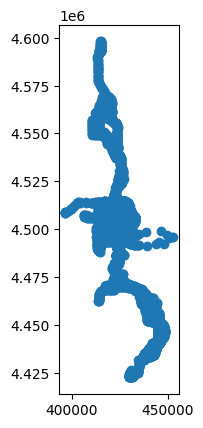

In [177]:
# create Transit node shapefile ------------------------------------------------
# print to console & log file
print("        create Transit node shapefile")
logFile.write("        create Transit node shapefile\n")


# use merged geometry to create gdf
gdf_Transit_Node_ByRoute = gpd.GeoDataFrame(df_Transit_Node_CalcStop_Master_Filter)


# export to shapefile
path_out_Transit_Node_shp = os.path.join(path_outfolder_Transit, out_Transit_Node_shp)

gdf_Transit_Node_ByRoute.to_file(
    path_out_Transit_Node_shp,
    driver='ESRI Shapefile'
)


# remove geometry from transit node gdf
df_Transit_Node_ByRoute = gdf_Transit_Node_ByRoute.drop(columns='geometry')


# calculate elapsed time -------------------------------------------------------
time_end_TransitShp     = time.time()
time_elapsed_TransitShp = time_end_TransitShp - time_begin_TransitShp

# format elapsed time (convert to string formated as 'HH:MM:SS.S')
time_elapsed_TransitShp_txt = gs.ElapsedTime(time_elapsed_TransitShp)

# print to console & log file
print("")
print("    done")
print("    elapsed time: "  +  time_elapsed_TransitShp_txt)

logFile.write("\n")
logFile.write("    done\n")
logFile.write("    elapsed time: "  +  time_elapsed_TransitShp_txt  +  "\n")



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
df_Transit_Node_ByRoute.to_csv("_check\\Transit_chk1 - df_Transit_Node_ByRoute.csv", index=False)

gdf_Transit_Node_ByRoute.plot()
df_Transit_Node_ByRoute

# close log file to see output of this step
#logFile.close()



Creating Walk Buffer File...
    create local bus buffer
        filter Transit links for local bus


,A,B,LINKID,MODE,OPERATOR,NAME,LONGNAME,LINKSEQ,STOPA,STOPB,DISTANCE,TAZID,LANES,FT,geometry
0,10031,27082,10031_27082,4,0,S455,S455,1,1,0,0.240831,780,7,1,"LINESTRING (423905.095 4537796.948, 423535.941..."
1,27082,27137,27082_27137,4,0,S455,S455,2,0,0,0.146744,775,2,2,"LINESTRING (423535.941 4537678.869, 423696.154..."
2,27137,27082,27137_27082,4,0,S455,S455,3,0,0,0.146744,775,2,2,"LINESTRING (423696.154 4537852.373, 423535.941..."
3,27082,27053,27082_27053,4,0,S455,S455,4,0,0,0.090994,775,2,3,"LINESTRING (423535.941 4537678.869, 423438.000..."
4,27053,27004,27053_27004,4,0,S455,S455,5,0,1,0.163048,780,2,3,"LINESTRING (423438.000 4537570.000, 423271.523..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9712,68837,71558,68837_71558,4,0,Cedar_Exp,Cedar_Exp,139,0,0,0.153537,2724,1,4,"LINESTRING (429713.730 4469461.277, 429960.821..."
9713,71558,71563,71558_71563,4,0,Cedar_Exp,Cedar_Exp,140,0,0,0.133508,2728,1,4,"LINESTRING (429960.821 4469462.274, 430175.611..."
9714,71563,68834,71563_68834,4,0,Cedar_Exp,Cedar_Exp,141,0,0,0.048033,2724,1,4,"LINESTRING (430175.611 4469456.788, 430252.897..."
9715,68834,68833,68834_68833,4,0,Cedar_Exp,Cedar_Exp,142,0,0,0.098470,2725,1,4,"LINESTRING (430252.897 4469455.310, 430411.343..."


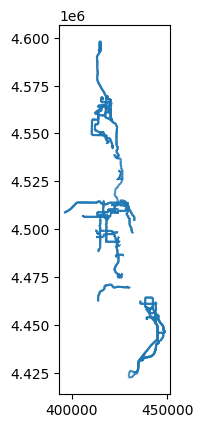

In [178]:
# ============================================================================================================
# Create Walk Buffer File
# ============================================================================================================

# print to console & log file
print("")
print("")
print("Creating Walk Buffer File...")

logFile.write("\n")
logFile.write("\n")
logFile.write("Creating Walk Buffer Update File...\n")


# get time (in seconds) --------------------------------------------------------
time_begin_WalkBuff = time.time()


# ----------------------------------------------------------------------------------------
# create local bus buffer
# ----------------------------------------------------------------------------------------
# print to console & log file
print("    create local bus buffer")
logFile.write("    create local bus buffer\n")


# filter Transit links for local bus -------------------------------------------
# print to console & log file
print("        filter Transit links for local bus")
logFile.write("        filter Transit links for local bus\n")


#filter data to only include local bus mode
gdf_Transit_LocalRoutes = gdf_Transit_Link[gdf_Transit_Link['MODE']==4]



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Transit_LocalRoutes.to_csv("_check\\Buffer_chk1 - gdf_Transit_LocalRoutes.csv", index=False)

gdf_Transit_LocalRoutes.plot()
gdf_Transit_LocalRoutes

# close log file to see output of this step
#logFile.close()

        remove duplicate links


,A,B,LINKID,MODE,DISTANCE,TAZID,LANES,FT,geometry
0,10031,27082,10031_27082,4,0.240831,780,7,1,"LINESTRING (423905.095 4537796.948, 423535.941..."
1,27082,27137,27082_27137,4,0.146744,775,2,2,"LINESTRING (423535.941 4537678.869, 423696.154..."
2,27137,27082,27137_27082,4,0.146744,775,2,2,"LINESTRING (423696.154 4537852.373, 423535.941..."
3,27082,27053,27082_27053,4,0.090994,775,2,3,"LINESTRING (423535.941 4537678.869, 423438.000..."
4,27053,27004,27053_27004,4,0.163048,780,2,3,"LINESTRING (423438.000 4537570.000, 423271.523..."
...,...,...,...,...,...,...,...,...,...
4276,68837,71558,68837_71558,4,0.153537,2724,1,4,"LINESTRING (429713.730 4469461.277, 429960.821..."
4277,71558,71563,71558_71563,4,0.133508,2728,1,4,"LINESTRING (429960.821 4469462.274, 430175.611..."
4278,71563,68834,71563_68834,4,0.048033,2724,1,4,"LINESTRING (430175.611 4469456.788, 430252.897..."
4279,68834,68833,68834_68833,4,0.098470,2725,1,4,"LINESTRING (430252.897 4469455.310, 430411.343..."


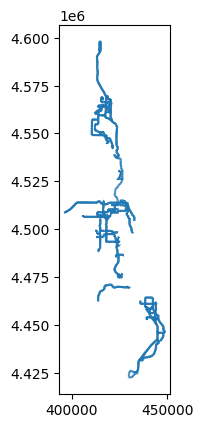

In [179]:
# remove duplicate links -------------------------------------------------------
# print to console & log file
print("        remove duplicate links")
logFile.write("        remove duplicate links\n")


# filter data to only include local bus mode
gdf_Transit_Local = gdf_Transit_LocalRoutes.drop_duplicates(
    subset=['A', 'B'],
    keep='first',
    ignore_index=True
)

# include relevant fields
gdf_Transit_Local = gdf_Transit_Local[
    ['A',
	 'B',
	 'LINKID',
	 'MODE',
	 'DISTANCE',
	 'TAZID',
	 'LANES',
	 'FT',
	 'geometry']
]



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Transit_Local.to_csv("_check\\Buffer_chk1 - gdf_Transit_Local.csv", index=False)

gdf_Transit_Local.plot()
gdf_Transit_Local

# close log file to see output of this step
#logFile.close()

        create local bus buffer


,A,B,LINKID,MODE,DISTANCE,TAZID,LANES,FT,geometry
0,10031,27082,10031_27082,4,0.240831,780,7,1,"POLYGON ((423732.061 4537065.734, 423671.019 4..."
1,27082,27137,27082_27137,4,0.146744,775,2,2,"POLYGON ((423223.208 4538289.089, 423268.291 4..."
2,27137,27082,27137_27082,4,0.146744,775,2,2,"POLYGON ((424008.887 4537242.153, 423963.804 4..."
3,27082,27053,27082_27053,4,0.090994,775,2,3,"POLYGON ((423916.576 4537139.462, 423872.071 4..."
4,27053,27004,27053_27004,4,0.163048,780,2,3,"POLYGON ((423769.114 4536958.760, 423726.687 4..."
...,...,...,...,...,...,...,...,...,...
4276,68837,71558,68837_71558,4,0.153537,2724,1,4,"POLYGON ((429958.224 4470106.006, 430021.333 4..."
4277,71558,71563,71558_71563,4,0.133508,2728,1,4,"POLYGON ((430192.047 4470100.316, 430255.045 4..."
4278,71563,68834,71563_68834,4,0.048033,2724,1,4,"POLYGON ((430265.206 4470098.930, 430328.232 4..."
4279,68834,68833,68834_68833,4,0.098470,2725,1,4,"POLYGON ((430422.933 4470096.090, 430485.964 4..."


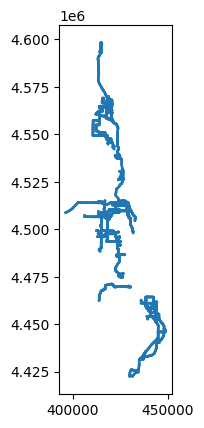

In [180]:
# create local bus buffer ------------------------------------------------------
# print to console & log file
print("        create local bus buffer")
logFile.write("        create local bus buffer\n")


# set buffer distance in meters (coordinate system is in meters: 1609.344m = 1mi)
meters_to_buffer_local = BuffDist_local * 1609.344

# create buffer (note: buffer does not retain original gdf attributes)
gdf_Transit_Local_buffer = gdf_Transit_Local.copy()

gdf_Transit_Local_buffer['geometry'] = gdf_Transit_Local.buffer(meters_to_buffer_local)
#buffer_Local = gdf_Transit_Mode4.buffer(meters_to_buffer, join_style=1, cap_style=1)



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Transit_Local_buffer.to_csv("_check\\Buffer_chk1 - gdf_Transit_Local_buffer.csv", index=False)

gdf_Transit_Local_buffer.plot()
gdf_Transit_Local_buffer

# close log file to see output of this step
#logFile.close()

        dissolve local bus buffer



,WalkBuff,geometry
0,1,"MULTIPOLYGON (((412194.749 4495677.638, 412174..."


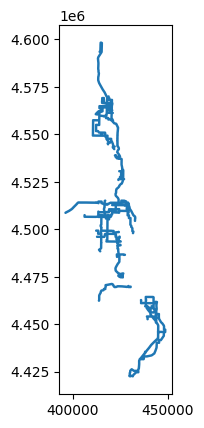

In [181]:
# dissolve local bus buffer ----------------------------------------------------
# print to console & log file
print("        dissolve local bus buffer")
print("")

logFile.write("        dissolve local bus buffer\n")
logFile.write("\n")


# dissolve buffer & add 'WaldBuff' field
gdf_Transit_Local_buffer_dissolve = gdf_Transit_Local_buffer.dissolve()

gdf_Transit_Local_buffer_dissolve['WalkBuff'] = 1

gdf_Transit_Local_buffer_dissolve = gdf_Transit_Local_buffer_dissolve[
    ['WalkBuff',
     'geometry']
]



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Transit_Local_buffer_dissolve.to_csv("_check\\Buffer_chk1 - gdf_Transit_Local_buffer_dissolve.csv", index=False)

gdf_Transit_Local_buffer_dissolve.plot()
gdf_Transit_Local_buffer_dissolve

# close log file to see output of this step
#logFile.close()

    create premium modes buffer
        filter Transit nodes for premium mode stops


,N,MODE,OPERATOR,NAME,LONGNAME,STOP,STOP4,STOP5,STOP6,STOP7,STOP8,STOP9,X,Y,TAZID,geometry
2927,24806,5,0,S1,S1,1,0,1,0,0,0,0,420741.21060,4.512612e+06,1061,POINT (420741.211 4512611.717)
2932,24956,5,0,S1,S1,1,0,1,0,0,0,0,420732.99970,4.513819e+06,1017,POINT (420733.000 4513818.926)
2933,25035,5,0,S1,S1,1,0,1,0,0,0,0,421262.00000,4.513812e+06,1017,POINT (421262.000 4513812.000)
2934,25021,5,0,S1,S1,1,0,1,0,0,0,0,420732.00000,4.514259e+06,984,POINT (420732.000 4514259.000)
2935,25111,5,0,S1,S1,1,0,1,0,0,0,0,420729.00000,4.514803e+06,980,POINT (420729.000 4514803.000)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6316,50066,7,0,POM_Rail,Point of Mountain Rail,1,0,0,0,1,0,0,439300.10625,4.452593e+06,2946,POINT (439300.106 4452593.045)
6322,29381,5,0,BRTNSDA_R,Ext of DavisSLCCon,1,0,1,0,0,0,0,430325.14838,4.511927e+06,1102,POINT (430325.148 4511927.427)
6323,10010,5,0,SoJoSandyC,South Jordan/Sandy Circulator,1,0,1,0,0,0,0,423760.00000,4.490625e+06,1973,POINT (423760.000 4490625.000)
6324,25439,6,0,S472X,S472X,1,0,0,1,0,0,0,425028.00000,4.512325e+06,1142,POINT (425028.000 4512325.000)


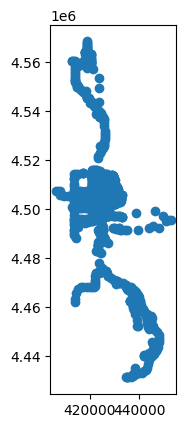

In [182]:
# ----------------------------------------------------------------------------------------
# create premium modes buffer
# ----------------------------------------------------------------------------------------
# print to console & log file
print("    create premium modes buffer")
logFile.write("    create premium modes buffer\n")


# filter Transit nodes for premium mode stops ----------------------------------
# print to console & log file
print("        filter Transit nodes for premium mode stops")
logFile.write("        filter Transit nodes for premium mode stops\n")


# filter data to only include local bus mode
gdf_Transit_PremiumRoutes = gdf_Transit_Node_ByRoute[gdf_Transit_Node_ByRoute['MODE']>4]

# filter data to only include stop nodes
gdf_Transit_Stop_PremiumRoutes = gdf_Transit_PremiumRoutes[gdf_Transit_PremiumRoutes['STOP']==1]



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Transit_PremiumRoutes.to_csv("_check\\Buffer_chk2 - gdf_Transit_PremiumRoutes.csv", index=False)
gdf_Transit_Stop_PremiumRoutes.to_csv("_check\\Buffer_chk2 - gdf_Transit_Stop_PremiumRoutes.csv", index=False)

gdf_Transit_Stop_PremiumRoutes.plot()
gdf_Transit_Stop_PremiumRoutes

# close log file to see output of this step
#logFile.close()

        remove duplicate stop nodes


,N,STOP,X,Y,TAZID,geometry
0,24806,1,420741.21060,4.512612e+06,1061,POINT (420741.211 4512611.717)
1,24956,1,420732.99970,4.513819e+06,1017,POINT (420733.000 4513818.926)
2,25035,1,421262.00000,4.513812e+06,1017,POINT (421262.000 4513812.000)
3,25021,1,420732.00000,4.514259e+06,984,POINT (420732.000 4514259.000)
4,25111,1,420729.00000,4.514803e+06,980,POINT (420729.000 4514803.000)
...,...,...,...,...,...,...
988,50057,1,438156.84827,4.457371e+06,2875,POINT (438156.848 4457370.930)
989,50067,1,438993.28274,4.454926e+06,2912,POINT (438993.283 4454925.617)
990,50066,1,439300.10625,4.452593e+06,2946,POINT (439300.106 4452593.045)
991,29381,1,430325.14838,4.511927e+06,1102,POINT (430325.148 4511927.427)


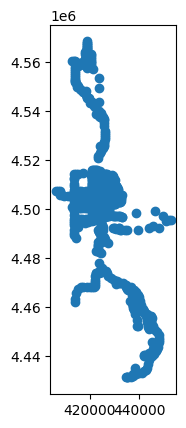

In [183]:
# remove duplicate stop nodes --------------------------------------------------
# print to console & log file
print("        remove duplicate stop nodes")
logFile.write("        remove duplicate stop nodes\n")


#filter data to only include local bus mode
gdf_Transit_Stop_Premium = gdf_Transit_Stop_PremiumRoutes.drop_duplicates(
    subset='N',
    keep='first',
    ignore_index=True
)

gdf_Transit_Stop_Premium = gdf_Transit_Stop_Premium[
    ['N',
	 'STOP',
	 'X',
	 'Y',
	 'TAZID',
	 'geometry']
]



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Transit_Stop_Premium.to_csv("_check\\Buffer_chk2 - gdf_Transit_Stop_Premium.csv", index=False)

gdf_Transit_Stop_Premium.plot()
gdf_Transit_Stop_Premium

# close log file to see output of this step
#logFile.close()

        create premium modes buffer


,N,STOP,X,Y,TAZID,geometry
0,24806,1,420741.21060,4.512612e+06,1061,"POLYGON ((421384.948 4512611.717, 421381.848 4..."
1,24956,1,420732.99970,4.513819e+06,1017,"POLYGON ((421376.737 4513818.926, 421373.638 4..."
2,25035,1,421262.00000,4.513812e+06,1017,"POLYGON ((421905.738 4513812.000, 421902.638 4..."
3,25021,1,420732.00000,4.514259e+06,984,"POLYGON ((421375.738 4514259.000, 421372.638 4..."
4,25111,1,420729.00000,4.514803e+06,980,"POLYGON ((421372.738 4514803.000, 421369.638 4..."
...,...,...,...,...,...,...
988,50057,1,438156.84827,4.457371e+06,2875,"POLYGON ((438800.586 4457370.930, 438797.486 4..."
989,50067,1,438993.28274,4.454926e+06,2912,"POLYGON ((439637.020 4454925.617, 439633.921 4..."
990,50066,1,439300.10625,4.452593e+06,2946,"POLYGON ((439943.844 4452593.045, 439940.744 4..."
991,29381,1,430325.14838,4.511927e+06,1102,"POLYGON ((430968.886 4511927.427, 430965.786 4..."


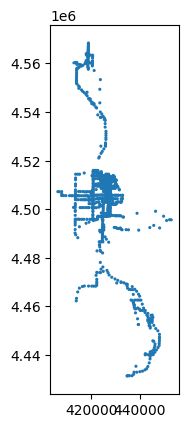

In [184]:
# create premium modes buffer --------------------------------------------------
# print to console & log file
print("        create premium modes buffer")
logFile.write("        create premium modes buffer\n")


# set buffer distance in meters (coordinate system is in meters: 1609.344m = 1mi)
meters_to_buffer_premium = BuffDist_premium * 1609.344

# create buffer (note: buffer does not retain original gdf attributes)
gdf_Transit_Premium_buffer = gdf_Transit_Stop_Premium.copy()

gdf_Transit_Premium_buffer['geometry'] = gdf_Transit_Premium_buffer.buffer(meters_to_buffer_premium)



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Transit_Premium_buffer.to_csv("_check\\Buffer_chk2 - gdf_Transit_Premium_buffer.csv", index=False)

gdf_Transit_Premium_buffer.plot()
gdf_Transit_Premium_buffer

# close log file to see output of this step
#logFile.close()

        dissolve premium modes buffer



,WalkBuff,geometry
0,1,"MULTIPOLYGON (((414173.727 4461799.553, 414122..."


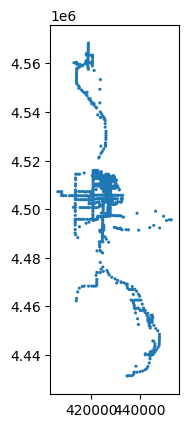

In [185]:
# dissolve premium modes buffer ------------------------------------------------
# print to console & log file
print("        dissolve premium modes buffer")
print("")

logFile.write("        dissolve premium modes buffer\n")
logFile.write("\n")


# dissolve buffer & add 'WaldBuff' field
gdf_Transit_Premium_buffer_dissolve = gdf_Transit_Premium_buffer.dissolve()

gdf_Transit_Premium_buffer_dissolve['WalkBuff'] = 1

gdf_Transit_Premium_buffer_dissolve = gdf_Transit_Premium_buffer_dissolve[
    ['WalkBuff',
     'geometry']
]



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Transit_Premium_buffer_dissolve.to_csv("_check\\Buffer_chk2 - gdf_Transit_Premium_buffer_dissolve.csv", index=False)

gdf_Transit_Premium_buffer_dissolve.plot()
gdf_Transit_Premium_buffer_dissolve

# close log file to see output of this step
#logFile.close()

    create combined local bus & premium modes buffer
        combine local bus & premium modes buffers


,A,B,LINKID,MODE,DISTANCE,TAZID_1,LANES,FT,N,STOP,X,Y,TAZID_2,geometry
0,10031.0,27082.0,10031_27082,4.0,0.240831,780.0,7.0,1.0,10031.0,1.0,423905.09490,4.537797e+06,780.0,"POLYGON ((423744.173 4538419.465, 423774.803 4..."
1,27082.0,27137.0,27082_27137,4.0,0.146744,775.0,2.0,2.0,10031.0,1.0,423905.09490,4.537797e+06,780.0,"POLYGON ((423976.776 4538431.726, 424032.211 4..."
2,27137.0,27082.0,27137_27082,4.0,0.146744,775.0,2.0,2.0,10031.0,1.0,423905.09490,4.537797e+06,780.0,"POLYGON ((423963.804 4537197.900, 423914.600 4..."
3,27082.0,27053.0,27082_27053,4.0,0.090994,775.0,2.0,3.0,10031.0,1.0,423905.09490,4.537797e+06,780.0,"POLYGON ((423565.147 4538321.944, 423628.038 4..."
4,27053.0,27004.0,27053_27004,4.0,0.163048,780.0,2.0,3.0,10031.0,1.0,423905.09490,4.537797e+06,780.0,"POLYGON ((423438.039 4538213.738, 423501.137 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50057.0,1.0,438156.84827,4.457371e+06,2875.0,"POLYGON ((438751.584 4457124.582, 438724.574 4..."
36516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50067.0,1.0,438993.28274,4.454926e+06,2912.0,"POLYGON ((438989.977 4454597.879, 438980.024 4..."
36517,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50066.0,1.0,439300.10625,4.452593e+06,2946.0,"POLYGON ((438764.858 4452235.404, 438732.380 4..."
36518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29381.0,1.0,430325.14838,4.511927e+06,1102.0,"POLYGON ((430202.119 4512268.132, 430203.174 4..."


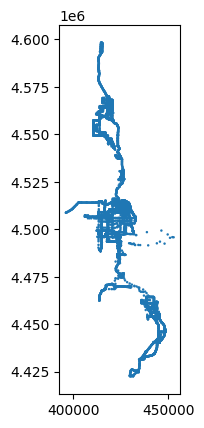

In [186]:
# ----------------------------------------------------------------------------------------
# create combined local bus & premium modes buffer
# ----------------------------------------------------------------------------------------
# print to console & log file
print("    create combined local bus & premium modes buffer")
logFile.write("    create combined local bus & premium modes buffer\n")

# combine local bus & premium modes buffers ------------------------------------
# print to console & log file
print("        combine local bus & premium modes buffers")
logFile.write("        combine local bus & premium modes buffers\n")


# union local bus & premium modes buffers
gdf_Transit_Combined_buffer = gdf_Transit_Local_buffer.overlay(gdf_Transit_Premium_buffer, how='union')



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Transit_Combined_buffer.plot()
gdf_Transit_Combined_buffer

# close log file to see output of this step
#logFile.close()

        dissolve combined buffers



,WalkBuff,geometry
0,1,"MULTIPOLYGON (((412378.008 4495424.104, 412331..."


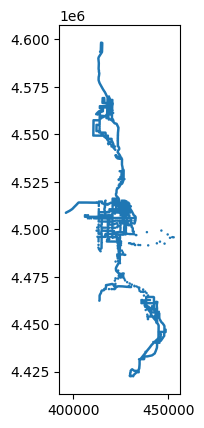

In [187]:
# dissolve combined buffers ----------------------------------------------------
# print to console & log file
print("        dissolve combined buffers")
print("")

logFile.write("        dissolve combined buffers\n")
logFile.write("\n")


# round before dissolving buffer to avoid floating point errors (9th decimal is too precise and causes overlap error)
gdf_Transit_Combined_buffer["geometry"] = gdf_Transit_Combined_buffer["geometry"].apply(lambda x: shapely.wkt.loads(shapely.wkt.dumps(x, rounding_precision=8)))

# add additional buffer in case of duplicated geometries
gdf_Transit_Combined_buffer['geometry'] = gdf_Transit_Combined_buffer['geometry'].buffer(1e-9)

# dissolve buffer & add 'WalkBuff' field
gdf_Transit_Combined_buffer_dissolve = gdf_Transit_Combined_buffer.dissolve()

gdf_Transit_Combined_buffer_dissolve['WalkBuff'] = 1

gdf_Transit_Combined_buffer_dissolve = gdf_Transit_Combined_buffer_dissolve[
    ['WalkBuff',
     'geometry']
]



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_Transit_Combined_buffer_dissolve.to_csv("_check\\Buffer_chk2 - gdf_Transit_Combined_buffer_dissolve.csv", index=False)

gdf_Transit_Combined_buffer_dissolve.plot()
gdf_Transit_Combined_buffer_dissolve

# close log file to see output of this step
#logFile.close()

In [453]:
# ----------------------------------------------------------------------------------------
# calculate Walk Buffer percent
# ----------------------------------------------------------------------------------------
# print to console & log file
print("    calculate Walk Buffer percent")
logFile.write("    calculate Walk Buffer percent\n")


# calculate TAZ area -----------------------------------------------------------
# print to console & log file
print("        calculate TAZ area")
logFile.write("        calculate TAZ area\n")


# intersect TAZ & buffer
gdf_TAZ_Area = gdf_TAZ.copy()

gdf_TAZ_Area['AreaTAZ'] = gdf_TAZ['geometry'].area



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_TAZ_Area

# close log file to see output of this step
#logFile.close()



    calculate Walk Buffer percent
        calculate TAZ area


,TAZID,TAZID_V832,SORT,CO_IDX,CO_TAZID,SUBAREAID,ACRES,DEVACRES,DEVPBLEPCT,X,Y,ADJ_XY,CO_FIPS,CO_NAME,CITY_FIPS,CITY_UGRC,CITY_NAME,DISTSUPER,DSUP_NAME,DISTLRG,DLRG_NAME,DISTMED,DMED_NAME,DISTSML,DSML_NAME,CBD,TERMTIME,PRKCSTPERM,PRKCSTTEMP,WALK100,ECOEDPASS,FREEFARE,REMM,PLANAREA,SUBPLNAREA,geometry,AreaTAZ
0,1,8,1,1,30001,1,582.086695,582.086695,1.00,412339.399850,4.603960e+06,1,3,BOX ELDER,0,NaN,Box Elder County North,1,Box Elder County,1,Box Elder County - WFRC,1,North of Brigham City,11,Small District 011,0,0,0.0,0.0,0,0,0,0,WFRC,Box Elder County,"POLYGON ((413249.900 4602832.400, 413246.600 4...",2.355623e+06
1,2,9,2,2,30002,1,135.465050,134.110399,0.99,412640.145346,4.606014e+06,0,3,BOX ELDER,0,NaN,Box Elder County North,1,Box Elder County,1,Box Elder County - WFRC,1,North of Brigham City,11,Small District 011,0,0,0.0,0.0,0,0,0,0,WFRC,Box Elder County,"POLYGON ((413063.900 4605180.900, 413060.900 4...",5.482081e+05
2,3,2,3,3,30003,1,663.377323,636.842231,0.96,408992.313015,4.603545e+06,0,3,BOX ELDER,0,NaN,Box Elder County North,1,Box Elder County,1,Box Elder County - WFRC,1,North of Brigham City,11,Small District 011,0,0,0.0,0.0,0,0,0,0,WFRC,Box Elder County,"POLYGON ((409586.800 4605183.500, 409604.000 4...",2.684595e+06
3,4,1,4,4,30004,1,375.207672,371.455595,0.99,410102.680272,4.604483e+06,0,3,BOX ELDER,0,NaN,Box Elder County North,1,Box Elder County,1,Box Elder County - WFRC,1,North of Brigham City,11,Small District 011,0,0,0.0,0.0,0,0,0,0,WFRC,Box Elder County,"POLYGON ((410625.000 4603458.800, 410636.800 4...",1.518413e+06
4,5,10,5,5,30005,1,1031.463233,1021.148600,0.99,413392.938145,4.603601e+06,0,3,BOX ELDER,0,NaN,Box Elder County North,1,Box Elder County,1,Box Elder County - WFRC,1,North of Brigham City,11,Small District 011,0,0,0.0,0.0,0,0,0,0,WFRC,Box Elder County,"POLYGON ((413071.499 4605049.409, 413071.500 4...",4.174187e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3541,3506,0,3542,1290,491290,1,329.216986,55.966888,0.17,451765.414346,4.466882e+06,0,49,UTAH,0,NaN,Eastside Mountains,7,Utah County,25,Utah County - East Mountains,68,Provo Canyon,681,Small District 681,0,0,0.0,0.0,0,0,0,0,MAG,NaN,"POLYGON ((452775.482 4467225.335, 452008.627 4...",1.332295e+06
3542,3508,0,3543,1292,491292,1,3449.109810,1207.188434,0.35,450266.978619,4.470844e+06,0,49,UTAH,0,NaN,Eastside Mountains,7,Utah County,25,Utah County - East Mountains,68,Provo Canyon,681,Small District 681,0,0,0.0,0.0,0,0,0,0,MAG,NaN,"POLYGON ((452357.500 4469309.000, 452382.500 4...",1.395806e+07
3543,3504,0,3544,1288,491288,1,1203.759358,0.000000,0.00,449014.603321,4.466119e+06,0,49,UTAH,0,NaN,Eastside Mountains,7,Utah County,25,Utah County - East Mountains,68,Provo Canyon,681,Small District 681,0,0,0.0,0.0,0,0,0,0,MAG,NaN,"POLYGON ((450980.664 4467431.971, 451003.208 4...",4.871445e+06
3544,3546,0,3545,1330,491330,1,59358.376922,0.000000,0.00,499554.707547,4.411684e+06,0,49,UTAH,0,NaN,Eastside Mountains,7,Utah County,25,Utah County - East Mountains,71,Spanish Fork Canyon,903,Small District 903,0,0,0.0,0.0,0,0,0,0,MAG,NaN,"POLYGON ((496052.140 4416631.950, 496120.880 4...",2.402150e+08


        intersect TAZ & local bus buffer


,TAZID,TAZID_V832,SORT,CO_IDX,CO_TAZID,SUBAREAID,ACRES,DEVACRES,DEVPBLEPCT,X,Y,ADJ_XY,CO_FIPS,CO_NAME,CITY_FIPS,CITY_UGRC,CITY_NAME,DISTSUPER,DSUP_NAME,DISTLRG,DLRG_NAME,DISTMED,DMED_NAME,DISTSML,DSML_NAME,CBD,TERMTIME,PRKCSTPERM,PRKCSTTEMP,WALK100,ECOEDPASS,FREEFARE,REMM,PLANAREA,SUBPLNAREA,AreaTAZ,WalkBuff,geometry
0,16,12,16,16,30016,1,754.355735,746.812178,0.99,413127.716901,4.598916e+06,0,3,BOX ELDER,8460,BGM,Brigham City,1,Box Elder County,1,Box Elder County - WFRC,1,North of Brigham City,11,Small District 011,0,0,0.0,0.0,0,0,0,0,WFRC,Box Elder County,3.052772e+06,1,"POLYGON ((414099.800 4598285.600, 414100.300 4..."
1,19,13,19,19,30019,1,210.973545,196.205397,0.93,414704.564697,4.598400e+06,0,3,BOX ELDER,8460,BGM,Brigham City,1,Box Elder County,1,Box Elder County - WFRC,1,North of Brigham City,11,Small District 011,0,0,0.0,0.0,0,0,0,0,WFRC,Box Elder County,8.537804e+05,1,"POLYGON ((415297.400 4598538.700, 415296.500 4..."
2,20,39,20,20,30020,1,217.308414,173.846732,0.80,415835.745699,4.598262e+06,0,3,BOX ELDER,8460,BGM,Brigham City,1,Box Elder County,1,Box Elder County - WFRC,3,Brigham City - North Perry,32,Small District 032,0,0,0.0,0.0,0,0,0,0,WFRC,Box Elder County,8.794167e+05,1,"POLYGON ((415909.500 4597885.800, 415891.500 4..."
3,23,30,23,23,30023,1,135.607746,135.607746,1.00,413757.732291,4.597661e+06,0,3,BOX ELDER,8460,BGM,Brigham City,1,Box Elder County,1,Box Elder County - WFRC,3,Brigham City - North Perry,31,Small District 031,0,0,0.0,0.0,0,0,0,0,WFRC,Box Elder County,5.487856e+05,1,"POLYGON ((414099.800 4598039.400, 414098.900 4..."
4,24,33,24,24,30024,1,101.657431,101.657431,1.00,414370.839276,4.597692e+06,0,3,BOX ELDER,8460,BGM,Brigham City,1,Box Elder County,1,Box Elder County - WFRC,3,Brigham City - North Perry,32,Small District 032,0,0,0.0,0.0,0,0,0,0,WFRC,Box Elder County,4.113934e+05,1,"POLYGON ((414670.800 4598046.400, 414670.700 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2191,3541,0,3510,1325,491325,1,18185.050417,0.000000,0.00,440130.804778,4.421564e+06,0,49,UTAH,0,NaN,Eastside Mountains,7,Utah County,25,Utah County - East Mountains,72,Payson Canyon - Nebo Loop,721,Small District 721,0,0,0.0,0.0,0,0,0,0,MAG,NaN,7.359235e+07,1,"MULTIPOLYGON (((435125.541 4425883.239, 435146..."
2192,3536,0,3512,1320,491320,1,98706.648257,0.000000,0.00,465305.650185,4.450928e+06,0,49,UTAH,0,NaN,Eastside Mountains,7,Utah County,25,Utah County - East Mountains,69,Hobble Creek Canyon,691,Small District 691,0,0,0.0,0.0,0,0,0,0,MAG,NaN,3.994520e+08,1,"POLYGON ((448651.423 4448650.286, 448621.203 4..."
2193,3535,0,3515,1319,491319,1,33112.263962,0.000000,0.00,452989.254566,4.461515e+06,0,49,UTAH,0,NaN,Eastside Mountains,7,Utah County,25,Utah County - East Mountains,68,Provo Canyon,681,Small District 681,0,0,0.0,0.0,0,0,0,0,MAG,NaN,1.340007e+08,1,"POLYGON ((444654.347 4462034.906, 444603.547 4..."
2194,3533,0,3516,1317,491317,1,14570.654837,0.000000,0.00,441607.262800,4.473344e+06,0,49,UTAH,0,NaN,Eastside Mountains,7,Utah County,25,Utah County - East Mountains,67,American Fork Canyon,671,Small District 671,0,0,0.0,0.0,0,0,0,0,MAG,NaN,5.896540e+07,1,"POLYGON ((437833.713 4470646.976, 437797.483 4..."


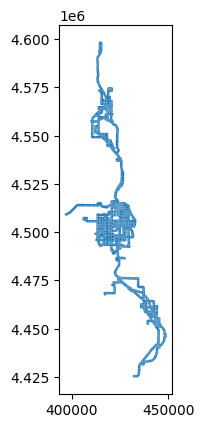

In [454]:
# intersect TAZ & local bus buffer ---------------------------------------------
# print to console & log file
print("        intersect TAZ & local bus buffer")
logFile.write("        intersect TAZ & local bus buffer\n")


# intersect TAZ & buffer
gdf_TAZ_Local_intersect = gdf_TAZ_Area.overlay(gdf_Transit_Local_buffer_dissolve, how='intersection')



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_TAZ_Local_intersect.plot()
gdf_TAZ_Local_intersect

# close log file to see output of this step
#logFile.close()

        calculate local bus Walk Buffer percent


,TAZID,AreaTAZ,WalkBuff,AreaLocal,WalkLocal
0,16,3.052772e+06,1,11912.705718,0.0
1,19,8.537804e+05,1,726362.504142,85.0
2,20,8.794167e+05,1,336850.798672,38.0
3,23,5.487856e+05,1,78442.524075,14.0
4,24,4.113934e+05,1,411393.390000,100.0
...,...,...,...,...,...
2191,3541,7.359235e+07,1,83506.639718,0.0
2192,3536,3.994520e+08,1,858167.782695,0.0
2193,3535,1.340007e+08,1,45458.527657,0.0
2194,3533,5.896540e+07,1,284990.954296,0.0


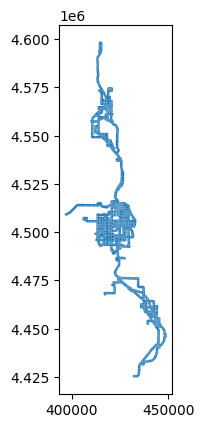

In [455]:
# calculate local bus Walk Buffer percent --------------------------------------
# print to console & log file
print("        calculate local bus Walk Buffer percent")
logFile.write("        calculate local bus Walk Buffer percent\n")


# calculate area of intersected polygon
gdf_WalkBuffer_Local = gdf_TAZ_Local_intersect.copy()

gdf_WalkBuffer_Local['AreaLocal'] = gdf_WalkBuffer_Local['geometry'].area


# calculate walk %
gdf_WalkBuffer_Local['WalkLocal'] = 0.0

gdf_WalkBuffer_Local.loc[gdf_WalkBuffer_Local['AreaTAZ']>0, 'WalkLocal'] = \
    gdf_WalkBuffer_Local['AreaLocal'] / gdf_WalkBuffer_Local['AreaTAZ'] * 100

# round to 1 decimal place
gdf_WalkBuffer_Local['WalkLocal'] = gdf_WalkBuffer_Local['WalkLocal'].round(0)


# select fields
df_WalkBuffer_Local = gdf_WalkBuffer_Local[
    ['TAZID',
     'AreaTAZ',
     'WalkBuff',
     'AreaLocal',
     'WalkLocal']
]



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_WalkBuffer_Local.to_csv("_check\\Buffer_chk3 - gdf_WalkBuffer_Local.csv", index=False)
df_WalkBuffer_Local.to_csv("_check\\Buffer_chk3 - df_WalkBuffer_Local.csv", index=False)

gdf_WalkBuffer_Local.plot()
df_WalkBuffer_Local

# close log file to see output of this step
#logFile.close()

        intersect TAZ & premium modes buffer


,TAZID,TAZID_V832,SORT,CO_IDX,CO_TAZID,SUBAREAID,ACRES,DEVACRES,DEVPBLEPCT,X,Y,ADJ_XY,CO_FIPS,CO_NAME,CITY_FIPS,CITY_UGRC,CITY_NAME,DISTSUPER,DSUP_NAME,DISTLRG,DLRG_NAME,DISTMED,DMED_NAME,DISTSML,DSML_NAME,CBD,TERMTIME,PRKCSTPERM,PRKCSTTEMP,WALK100,ECOEDPASS,FREEFARE,REMM,PLANAREA,SUBPLNAREA,AreaTAZ,WalkBuff,geometry
0,638,487,210,57,110057,1,373.899559,373.899559,1.00,422703.433107,4.553068e+06,0,11,DAVIS,71180,SWE,South Weber,5,Davis County,8,Davis County - North,19,HAFB Area,191,Small District 191,0,0,0.00,0.0,0,0,0,1,WFRC,Northern Davis County,1.513119e+06,1,"POLYGON ((423137.500 4553243.300, 423196.100 4..."
1,639,485,211,58,110058,1,260.363854,255.156577,0.98,423066.524182,4.553749e+06,0,11,DAVIS,71180,SWE,South Weber,5,Davis County,8,Davis County - North,19,HAFB Area,191,Small District 191,0,0,0.00,0.0,0,0,0,1,WFRC,Northern Davis County,1.053656e+06,1,"POLYGON ((423573.700 4553865.100, 423664.500 4..."
2,640,486,212,59,110059,1,131.409878,122.211186,0.93,423976.373876,4.553908e+06,0,11,DAVIS,71180,SWE,South Weber,5,Davis County,8,Davis County - North,19,HAFB Area,191,Small District 191,0,0,0.00,0.0,0,0,0,1,WFRC,Northern Davis County,5.317974e+05,1,"POLYGON ((424174.800 4553663.900, 424124.500 4..."
3,641,489,213,60,110060,1,494.420255,360.926786,0.73,424153.559194,4.552612e+06,0,11,DAVIS,71180,SWE,South Weber,5,Davis County,8,Davis County - North,19,HAFB Area,191,Small District 191,0,0,0.00,0.0,0,0,0,1,WFRC,Northern Davis County,2.000850e+06,1,"POLYGON ((423766.000 4552773.300, 423782.500 4..."
4,642,488,214,61,110061,1,251.574746,228.933019,0.91,422989.559434,4.552370e+06,0,11,DAVIS,71180,SWE,South Weber,5,Davis County,8,Davis County - North,19,HAFB Area,191,Small District 191,0,0,0.00,0.0,0,0,0,1,WFRC,Northern Davis County,1.018088e+06,1,"POLYGON ((423507.000 4552757.700, 423549.100 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
617,3012,2464,3369,796,490796,1,31.892227,31.892227,1.00,444407.545660,4.453234e+06,0,49,UTAH,62470,PVO,Provo,7,Utah County,21,Utah County - Utah Valley Central,59,Utah Valley - Downtown Provo,591,Small District 591,0,0,0.00,0.0,0,0,0,1,MAG,Central Utah County,1.290634e+05,1,"POLYGON ((444262.753 4453455.556, 444408.393 4..."
618,2881,2278,3373,665,490665,1,69.038726,69.038726,1.00,437497.549665,4.459169e+06,0,49,UTAH,57300,ORE,Orem,7,Utah County,21,Utah County - Utah Valley Central,58,Utah Valley - North Central,584,Small District 584,0,0,0.00,0.0,0,0,0,1,MAG,Central Utah County,2.793901e+05,1,"POLYGON ((437794.973 4459286.306, 437839.123 4..."
619,2867,2338,3375,651,490651,1,69.436627,69.436627,1.00,442283.150311,4.459002e+06,0,49,UTAH,57300,ORE,Orem,7,Utah County,21,Utah County - Utah Valley Central,58,Utah Valley - North Central,583,Small District 583,0,0,0.00,0.0,0,0,0,1,MAG,Central Utah County,2.810003e+05,1,"POLYGON ((442512.173 4458855.546, 442519.113 4..."
620,2849,2326,3376,633,490633,1,85.180750,85.180750,1.00,439698.508463,4.459160e+06,0,49,UTAH,57300,ORE,Orem,7,Utah County,21,Utah County - Utah Valley Central,58,Utah Valley - North Central,585,Small District 585,0,5,0.75,2.0,100,2000,0,1,MAG,Central Utah County,3.447145e+05,1,"POLYGON ((440083.743 4458946.176, 440084.978 4..."


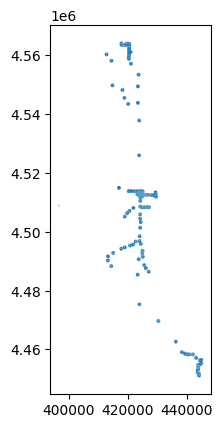

In [456]:
# intersect TAZ & premium modes buffer -----------------------------------------
# print to console & log file
print("        intersect TAZ & premium modes buffer")
logFile.write("        intersect TAZ & premium modes buffer\n")


# intersect TAZ & buffer
gdf_TAZ_Premium_intersect = gdf_TAZ_Area.overlay(gdf_Transit_Premium_buffer_dissolve, how='intersection')



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_TAZ_Premium_intersect.plot()
gdf_TAZ_Premium_intersect

# close log file to see output of this step
#logFile.close()

        calculate premium modes Walk Buffer percent


,TAZID,AreaTAZ,WalkBuff,AreaPrem,WalkPrem
0,638,1.513119e+06,1,291279.963285,19.0
1,639,1.053656e+06,1,344425.066057,33.0
2,640,5.317974e+05,1,261585.260471,49.0
3,641,2.000850e+06,1,355961.388633,18.0
4,642,1.018088e+06,1,46528.049235,5.0
...,...,...,...,...,...
617,3012,1.290634e+05,1,128533.246186,100.0
618,2881,2.793901e+05,1,40451.647113,14.0
619,2867,2.810003e+05,1,111268.332570,40.0
620,2849,3.447145e+05,1,161096.847052,47.0


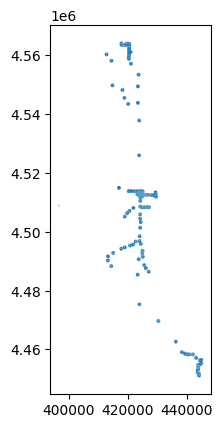

In [457]:
# calculate premium modes Walk Buffer percent ----------------------------------
# print to console & log file
print("        calculate premium modes Walk Buffer percent")
logFile.write("        calculate premium modes Walk Buffer percent\n")


# calculate area of intersected polygon
gdf_WalkBuffer_Premium = gdf_TAZ_Premium_intersect.copy()

gdf_WalkBuffer_Premium['AreaPrem'] = gdf_WalkBuffer_Premium['geometry'].area


# calculate walk %
gdf_WalkBuffer_Premium['WalkPrem'] = 0.0

gdf_WalkBuffer_Premium.loc[gdf_WalkBuffer_Premium['AreaTAZ']>0, 'WalkPrem'] = \
    gdf_WalkBuffer_Premium['AreaPrem'] / gdf_WalkBuffer_Premium['AreaTAZ'] * 100

# round to 1 decimal place
gdf_WalkBuffer_Premium['WalkPrem'] = gdf_WalkBuffer_Premium['WalkPrem'].round(0)


# select fields
df_WalkBuffer_Premium = gdf_WalkBuffer_Premium[
    ['TAZID',
     'AreaTAZ',
     'WalkBuff',
     'AreaPrem',
     'WalkPrem']
]



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_WalkBuffer_Premium.to_csv("_check\\Buffer_chk3 - gdf_WalkBuffer_Premium.csv", index=False)
df_WalkBuffer_Premium.to_csv("_check\\Buffer_chk3 - df_WalkBuffer_Premium.csv", index=False)

gdf_WalkBuffer_Premium.plot()
df_WalkBuffer_Premium

# close log file to see output of this step
#logFile.close()

        intersect TAZ & combined buffers


,TAZID,TAZID_V832,SORT,CO_IDX,CO_TAZID,SUBAREAID,ACRES,DEVACRES,DEVPBLEPCT,X,Y,ADJ_XY,CO_FIPS,CO_NAME,CITY_FIPS,CITY_UGRC,CITY_NAME,DISTSUPER,DSUP_NAME,DISTLRG,DLRG_NAME,DISTMED,DMED_NAME,DISTSML,DSML_NAME,CBD,TERMTIME,PRKCSTPERM,PRKCSTTEMP,WALK100,ECOEDPASS,FREEFARE,REMM,PLANAREA,SUBPLNAREA,AreaTAZ,WalkBuff,geometry
0,16,12,16,16,30016,1,754.355735,746.812178,0.99,413127.716901,4.598916e+06,0,3,BOX ELDER,8460,BGM,Brigham City,1,Box Elder County,1,Box Elder County - WFRC,1,North of Brigham City,11,Small District 011,0,0,0.0,0.0,0,0,0,0,WFRC,Box Elder County,3.052772e+06,1,"POLYGON ((414099.800 4598285.600, 414100.300 4..."
1,19,13,19,19,30019,1,210.973545,196.205397,0.93,414704.564697,4.598400e+06,0,3,BOX ELDER,8460,BGM,Brigham City,1,Box Elder County,1,Box Elder County - WFRC,1,North of Brigham City,11,Small District 011,0,0,0.0,0.0,0,0,0,0,WFRC,Box Elder County,8.537804e+05,1,"POLYGON ((415297.400 4598538.700, 415296.500 4..."
2,20,39,20,20,30020,1,217.308414,173.846732,0.80,415835.745699,4.598262e+06,0,3,BOX ELDER,8460,BGM,Brigham City,1,Box Elder County,1,Box Elder County - WFRC,3,Brigham City - North Perry,32,Small District 032,0,0,0.0,0.0,0,0,0,0,WFRC,Box Elder County,8.794167e+05,1,"POLYGON ((415909.500 4597885.800, 415891.500 4..."
3,23,30,23,23,30023,1,135.607746,135.607746,1.00,413757.732291,4.597661e+06,0,3,BOX ELDER,8460,BGM,Brigham City,1,Box Elder County,1,Box Elder County - WFRC,3,Brigham City - North Perry,31,Small District 031,0,0,0.0,0.0,0,0,0,0,WFRC,Box Elder County,5.487856e+05,1,"POLYGON ((414099.800 4598039.400, 414098.900 4..."
4,24,33,24,24,30024,1,101.657431,101.657431,1.00,414370.839276,4.597692e+06,0,3,BOX ELDER,8460,BGM,Brigham City,1,Box Elder County,1,Box Elder County - WFRC,3,Brigham City - North Perry,32,Small District 032,0,0,0.0,0.0,0,0,0,0,WFRC,Box Elder County,4.113934e+05,1,"POLYGON ((414670.800 4598046.400, 414670.700 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2215,3541,0,3510,1325,491325,1,18185.050417,0.000000,0.00,440130.804778,4.421564e+06,0,49,UTAH,0,NaN,Eastside Mountains,7,Utah County,25,Utah County - East Mountains,72,Payson Canyon - Nebo Loop,721,Small District 721,0,0,0.0,0.0,0,0,0,0,MAG,NaN,7.359235e+07,1,"MULTIPOLYGON (((435125.541 4425883.239, 435146..."
2216,3536,0,3512,1320,491320,1,98706.648257,0.000000,0.00,465305.650185,4.450928e+06,0,49,UTAH,0,NaN,Eastside Mountains,7,Utah County,25,Utah County - East Mountains,69,Hobble Creek Canyon,691,Small District 691,0,0,0.0,0.0,0,0,0,0,MAG,NaN,3.994520e+08,1,"POLYGON ((448651.423 4448650.286, 448621.203 4..."
2217,3535,0,3515,1319,491319,1,33112.263962,0.000000,0.00,452989.254566,4.461515e+06,0,49,UTAH,0,NaN,Eastside Mountains,7,Utah County,25,Utah County - East Mountains,68,Provo Canyon,681,Small District 681,0,0,0.0,0.0,0,0,0,0,MAG,NaN,1.340007e+08,1,"POLYGON ((444654.347 4462034.906, 444603.547 4..."
2218,3533,0,3516,1317,491317,1,14570.654837,0.000000,0.00,441607.262800,4.473344e+06,0,49,UTAH,0,NaN,Eastside Mountains,7,Utah County,25,Utah County - East Mountains,67,American Fork Canyon,671,Small District 671,0,0,0.0,0.0,0,0,0,0,MAG,NaN,5.896540e+07,1,"POLYGON ((437833.713 4470646.976, 437797.483 4..."


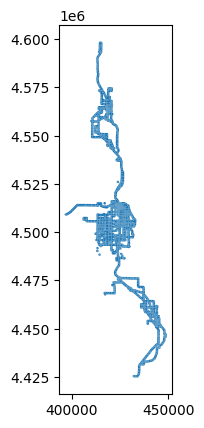

In [458]:
# intersect TAZ & combined buffers ---------------------------------------------
# print to console & log file
print("        intersect TAZ & combined buffers")
logFile.write("        intersect TAZ & combined buffers\n")


# intersect TAZ & buffer
gdf_TAZ_Combined_intersect = gdf_TAZ_Area.overlay(gdf_Transit_Combined_buffer_dissolve, how='intersection')



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_TAZ_Combined_intersect.plot()
gdf_TAZ_Combined_intersect

# close log file to see output of this step
#logFile.close()

        calculate combined Walk Buffer percent


,TAZID,AreaTAZ,WalkBuff,AreaComb,WalkComb
0,16,3.052772e+06,1,11912.705718,0.0
1,19,8.537804e+05,1,726362.504142,85.0
2,20,8.794167e+05,1,336850.798671,38.0
3,23,5.487856e+05,1,78442.524076,14.0
4,24,4.113934e+05,1,411393.390000,100.0
...,...,...,...,...,...
2215,3541,7.359235e+07,1,83506.639716,0.0
2216,3536,3.994520e+08,1,858167.782692,0.0
2217,3535,1.340007e+08,1,45458.527657,0.0
2218,3533,5.896540e+07,1,284990.954295,0.0


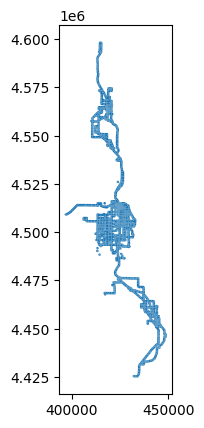

In [459]:
# calculate combined Walk Buffer percent ---------------------------------------
# print to console & log file
print("        calculate combined Walk Buffer percent")
logFile.write("        calculate combined Walk Buffer percent\n")


# calculate area of intersected polygon
gdf_WalkBuffer_Combined = gdf_TAZ_Combined_intersect.copy()

gdf_WalkBuffer_Combined['AreaComb'] = gdf_WalkBuffer_Combined['geometry'].area


# calculate walk %
gdf_WalkBuffer_Combined['WalkComb'] = 0.0

gdf_WalkBuffer_Combined.loc[gdf_WalkBuffer_Combined['AreaTAZ']>0, 'WalkComb'] = \
    gdf_WalkBuffer_Combined['AreaComb'] / gdf_WalkBuffer_Combined['AreaTAZ'] * 100

# round to 1 decimal place
gdf_WalkBuffer_Combined['WalkComb'] = gdf_WalkBuffer_Combined['WalkComb'].round(0)


# select fields
df_WalkBuffer_Combined = gdf_WalkBuffer_Combined[
    ['TAZID',
     'AreaTAZ',
     'WalkBuff',
     'AreaComb',
     'WalkComb']
]


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_WalkBuffer_Combined.to_csv("_check\\Buffer_chk3 - gdf_WalkBuffer_Combined.csv", index=False)
df_WalkBuffer_Combined.to_csv("_check\\Buffer_chk3 - df_WalkBuffer_Combined.csv", index=False)

gdf_WalkBuffer_Combined.plot()
df_WalkBuffer_Combined

# close log file to see output of this step
#logFile.close()

        create final Walk Buffer shapefile

    done
    elapsed time: 00:00:19.0


,TAZID,WalkPct,WALK100,WalkComb,WalkLocal,WalkPrem,AreaTAZ,AreaComb,AreaLocal,AreaPrem,geometry
0,1,0.0,0,0.0,0.0,0.0,2.355623e+06,0.0,0.0,0.0,"POLYGON ((413249.900 4602832.400, 413246.600 4..."
1,2,0.0,0,0.0,0.0,0.0,5.482081e+05,0.0,0.0,0.0,"POLYGON ((413063.900 4605180.900, 413060.900 4..."
2,3,0.0,0,0.0,0.0,0.0,2.684595e+06,0.0,0.0,0.0,"POLYGON ((409586.800 4605183.500, 409604.000 4..."
3,4,0.0,0,0.0,0.0,0.0,1.518413e+06,0.0,0.0,0.0,"POLYGON ((410625.000 4603458.800, 410636.800 4..."
4,5,0.0,0,0.0,0.0,0.0,4.174187e+06,0.0,0.0,0.0,"POLYGON ((413071.499 4605049.409, 413071.500 4..."
...,...,...,...,...,...,...,...,...,...,...,...
3541,3506,0.0,0,0.0,0.0,0.0,1.332295e+06,0.0,0.0,0.0,"POLYGON ((452775.482 4467225.335, 452008.627 4..."
3542,3508,0.0,0,0.0,0.0,0.0,1.395806e+07,0.0,0.0,0.0,"POLYGON ((452357.500 4469309.000, 452382.500 4..."
3543,3504,0.0,0,0.0,0.0,0.0,4.871445e+06,0.0,0.0,0.0,"POLYGON ((450980.664 4467431.971, 451003.208 4..."
3544,3546,0.0,0,0.0,0.0,0.0,2.402150e+08,0.0,0.0,0.0,"POLYGON ((496052.140 4416631.950, 496120.880 4..."


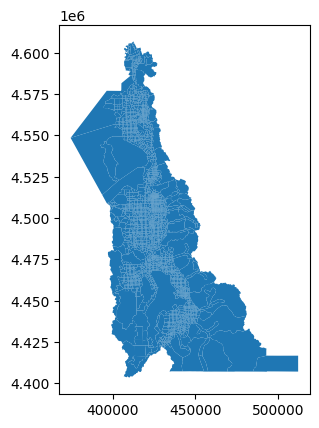

In [460]:
# create final Walk Buffer shapefile -------------------------------------------
# print to console & log file
print("        create final Walk Buffer shapefile")
logFile.write("        create final Walk Buffer shapefile\n")


# process TAZ gdf & combined, local bus, & premium modes buffer df for final Walk Buffer merge
gdf_TAZ_Area_temp = gdf_TAZ_Area[
    ['TAZID',
     'WALK100',
     'AreaTAZ',
     'geometry']
]

df_WalkBuffer_Combined_temp = df_WalkBuffer_Combined[
    ['TAZID',
     'WalkComb',
     'AreaComb']
]

df_WalkBuffer_Local_temp = df_WalkBuffer_Local[
    ['TAZID',
     'WalkLocal',
     'AreaLocal']
]

df_WalkBuffer_Premium_temp = df_WalkBuffer_Premium[
    ['TAZID',
     'WalkPrem',
     'AreaPrem']
]


# merge buffer data to TAZ
gdf_TAZ_WalkBuffer = pd.DataFrame.merge(
    gdf_TAZ_Area_temp,
    df_WalkBuffer_Combined_temp,
    how="left",
    left_on='TAZID',
    right_on='TAZID'
)

gdf_TAZ_WalkBuffer = pd.DataFrame.merge(
    gdf_TAZ_WalkBuffer,
    df_WalkBuffer_Local_temp,
    how="left",
    left_on='TAZID',
    right_on='TAZID'
)

gdf_TAZ_WalkBuffer = pd.DataFrame.merge(
    gdf_TAZ_WalkBuffer,
    df_WalkBuffer_Premium_temp,
    how="left",
    left_on='TAZID',
    right_on='TAZID'
)


# fill na data
gdf_TAZ_WalkBuffer = gdf_TAZ_WalkBuffer.fillna(0)


# calculate final walk % field
gdf_TAZ_WalkBuffer['WalkPct'] = gdf_TAZ_WalkBuffer['WalkComb']
gdf_TAZ_WalkBuffer.loc[gdf_TAZ_WalkBuffer['WALK100']>0, 'WalkPct'] = gdf_TAZ_WalkBuffer['WALK100']


# write out final Walk Buffer table & shapefile
gdf_TAZ_WalkBuffer = gdf_TAZ_WalkBuffer[
    ['TAZID',
     'WalkPct',
     'WALK100',
     'WalkComb',
     'WalkLocal',
     'WalkPrem',
     'AreaTAZ',
     'AreaComb',
     'AreaLocal',
     'AreaPrem',
     'geometry']
]


# export to shapefile
path_out_WalkBuffer_shp = os.path.join(path_outfolder_WalkBuffer, out_WalkBuffer_shp)

gdf_TAZ_WalkBuffer.to_file(
    path_out_WalkBuffer_shp,
    driver='ESRI Shapefile'
)


# calculate elapsed time -------------------------------------------------------
time_end_WalkBuff     = time.time()
time_elapsed_WalkBuff = time_end_WalkBuff - time_begin_WalkBuff

# format elapsed time (convert to string formated as 'HH:MM:SS.S')
time_elapsed_WalkBuff_txt = gs.ElapsedTime(time_elapsed_WalkBuff)

# print to console & log file
print("")
print("    done")
print("    elapsed time: "  +  time_elapsed_WalkBuff_txt)

logFile.write("\n")
logFile.write("    done\n")
logFile.write("    elapsed time: "  +  time_elapsed_WalkBuff_txt  +  "\n")



# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# (jupyter notebooks only)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# check files
gdf_TAZ_WalkBuffer.to_csv("_check\\Buffer_chk4 - gdf_TAZ_WalkBuffer.csv", index=False)

gdf_TAZ_WalkBuffer.plot()
gdf_TAZ_WalkBuffer

# close log file to see output of this step
#logFile.close()

In [ ]:
# ============================================================================================================
# Finish Script
# ============================================================================================================
#print to console & log file
print("\n")
print("")
print("All Finished...")

logFile.write("\n")
logFile.write("\n")
logFile.write("All Finished..." + "\n")


# calculate elapsed time -------------------------------------------------------
time_end     = time.time()
time_elapsed = time_end - time_begin

# format elapsed time (convert to string formated as 'HH:MM:SS.S')
time_elapsed_txt = gs.ElapsedTime(time_elapsed)


# format time stamps (convert to a string tuple formated as 'YYYY-MM-DD, HH:MM:SS')
time_begin_txt = time.strftime('%Y-%m-%d, %H:%M:%S', time.localtime(time_begin))
time_end_txt   = time.strftime('%Y-%m-%d, %H:%M:%S', time.localtime(time_end  ))


# print to console & log file
print("")
print("    Start   Time: "  +  time_begin_txt)
print("    End     Time: "  +  time_end_txt)
print("    Elapsed Time: "  +  time_elapsed_txt)
print("")

logFile.write("\n")
logFile.write("    Start   Time: "  +  time_begin_txt    +  "\n")
logFile.write("    End     Time: "  +  time_end_txt      +  "\n")
logFile.write("    Elapsed Time: "  +  time_elapsed_txt  +  "\n")
logFile.write("\n")


#close log file ----------------------------------------------------------------
logFile.close()




All Finished...

    Start   Time: 2024-03-13, 16:10:46
    End     Time: 2024-03-13, 16:12:18
    Elapsed Time: 00:01:31.8

